# ESG Regulation and Market Efficiency in BRICS+ Countries

**Master's thesis — empirical analysis**
Anelia Kurakina, HSE University, Faculty of Economic Sciences, 2026

This notebook contains the full empirical pipeline that produces the results reported in
the thesis "The Link Between ESG Regulation and Market Efficiency in BRICS+ Countries".
The analysis combines:

- **S&P Trucost Environmental** (WRDS) — Weighted Environmental Disclosure scores and pillar metrics
- **Compustat Global Fundamentals Annual** (WRDS) — firm-level financial controls
- **Compustat Global Security Daily** (WRDS) — daily prices for market-model proxies
- **World Bank Worldwide Governance Indicators** — `rule_of_law` and `regulatory_quality`

The final regression-ready panel covers **9 BRICS+ countries**, **2017–2024**,
**28,647 firm-year observations** on **7,389 non-financial firms**.

## Notebook structure

1. **Configuration** — paths, helpers
2. **Trucost EDA** — coverage, environmental disclosure variables
3. **Sample construction** — BRICS+ 9 countries, 2017–2024
4. **Compustat & Security Daily** — financial controls and daily prices
5. **Three-way intersection** — firms with all three data sources
6. **Daily returns** — log returns + equal-weighted country market return
7. **Market-model metrics** — Volatility, Synchronicity, IdioVol per firm-year
8. **Panel assembly** — merge Trucost + Compustat + metrics, Mandatory indicator
9. **WGI** — institutional quality variables
10. **Winsorisation and clean panel** — final regression-ready dataset
11. **Diagnostics** — VIF, baseline OLS
12. **Main FE regressions** — three Y, with firm and year fixed effects
13. **Robustness sub-samples** — 7 specifications
14. **Event-time DiD** — staggered design
15. **Country-by-country regressions**
16. **H3: triple interaction**
17. **Country event studies** — China 2024, India 2022
18. **Lag specification**
19. **Summary table**
20. **Pillar regressions and figures**
21. **Balanced-panel disclosure heatmap**
22. **Lag-specification R² check**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

The single variable `DATA_DIR` controls where the input and intermediate files live.
Change it to point at your local directory.

In [8]:
"""
Configuration and imports.

`DATA_DIR` is the only path that needs to be adjusted to run this notebook
on a different machine. By default it points at the current directory; on
Google Colab you would typically point it at a mounted Drive folder, e.g.
`/content/drive/MyDrive/diploma_esg/`.
"""
import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# === EDIT THIS PATH ===
DATA_DIR = Path("/content/drive/MyDrive/diploma_esg/")
DATA_DIR.mkdir(exist_ok=True)

# Source files expected in DATA_DIR (raw extracts from WRDS / World Bank):
#   - gxpvubiao4zdn1ro.csv     : Trucost Environmental (annual)
#   - diplom_findata.csv       : Compustat Global Fundamentals Annual
#   - securitydaily.csv        : Compustat Global Security Daily
#   - wgi.xlsx                 : World Bank Worldwide Governance Indicators

# Display options for convenience
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(f"DATA_DIR = {DATA_DIR.resolve()}")
print(f"Files in DATA_DIR: {sorted(p.name for p in DATA_DIR.iterdir()) if DATA_DIR.exists() else '(empty)'}")

DATA_DIR = /content/drive/MyDrive/diploma_esg
Files in DATA_DIR: ['diplom_findata.csv', 'disclosure_heatmap_balanced.xlsx', 'esg_filtered_data', 'esg_filtered_data.csv', 'fig1_env_disc_dist.png', 'fig2_disclosure_heatmap.png', 'fig3_synchronicity_by_country.png', 'fig4_disclosure_by_mandatory.png', 'fig5_synchronicity_dist.png', 'fig6_main_forest.png', 'fig7_robustness_forest.png', 'fig8_h3_marginal_effect.png', 'fig9_time_trends.png', 'final_gvkeys.txt', 'firm_year_metrics.parquet', 'firm_year_metrics_clean.parquet', 'gvkeys_brics9.txt', 'gvkeys_brics9_clean.txt', 'gxpvubiao4zdn1ro.csv', 'market_return_ew.parquet', 'ml_importance_idio_gb.xlsx', 'ml_importance_idio_rf.xlsx', 'ml_importance_sync_gb.xlsx', 'ml_importance_sync_rf.xlsx', 'ml_importance_vol_gb.xlsx', 'ml_importance_vol_rf.xlsx', 'panel_final.parquet', 'panel_final_full.parquet', 'panel_regression_ready.parquet', 'panel_with_mandatory.parquet', 'pillar_results.xlsx', 'returns_daily.parquet', 'secdaily_filtered.parquet', 'sec

## 2. Trucost Environmental: exploratory analysis

We load the raw Trucost extract and inspect coverage by country, year and the main
disclosure-quality fields. The central variable is `di_329704` — **Weighted Disclosure: Environmental**,
which takes values in 0–100 and captures the share of physical environmental indicators
that a firm publicly discloses, weighted by indicator materiality.

In [9]:
# Load the raw Trucost extract (file name as provided by WRDS export)
df_raw = pd.read_csv(
    DATA_DIR / "gxpvubiao4zdn1ro.csv",
    sep=",",
    encoding="utf-8-sig",
    on_bad_lines="skip",
)

print(f"Raw rows: {len(df_raw):,}")
df_raw.head()

Raw rows: 580,478


,institutionid,periodenddate,companyid,gvkey,ticker,companyname,status,companytype,simpleindustry,incorporation_country,country,reportedcurrencyisocode,tcprimarysectorid,fiscalyear,di_319405,di_319407,di_319409,di_319408,di_319411,di_319413,di_319416,di_319414,di_319415,di_319522,di_319553,di_319555,di_319558,di_319564,di_319570,di_327790,di_329704,di_387688,di_387689,di_387717,di_319403_text,di_329689_text,di_368758_text,di_376014_text
0,4015231,2018-12-31,9681732,268696.0,1180,The Saudi National Bank,Operating,Public Company,Banks,Saudi Arabia,Saudi Arabia,USD,52A000,2018,6.946351,0.765672,25.294258,2.630324,40053.470796,4414.952000,0.0,15166.754063,145849.651603,5766.117121,0.679654,0.0,64.090069,369550.845896,NaN,1.431354,0.0,4.0,4.0,4.0,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Fully Researched
1,4015231,2019-12-31,9681732,268696.0,1180,The Saudi National Bank,Operating,Public Company,Banks,Saudi Arabia,Saudi Arabia,USD,52A000,2019,6.565869,0.710101,23.633236,2.388795,42222.971632,4566.430832,0.0,15361.563695,151977.671756,6430.675449,0.732795,0.0,62.235262,400214.773120,NaN,1.390659,0.0,4.0,4.0,4.0,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Fully Researched
2,4015231,2020-12-31,9681732,268696.0,1180,The Saudi National Bank,Operating,Public Company,Banks,Saudi Arabia,Saudi Arabia,USD,52A000,2020,6.830000,0.645000,23.990000,2.714000,35503.243000,3353.496000,0.0,14110.414000,124709.154000,5198.300850,0.608000,0.0,61.972000,322149.243000,NaN,1.403055,0.0,4.0,4.0,4.0,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Fully Researched
3,4015231,2021-12-31,9681732,268696.0,1180,The Saudi National Bank,Operating,Public Company,Banks,Saudi Arabia,Saudi Arabia,USD,52A000,2021,5.472000,0.747000,23.639000,1.408000,35791.033000,4883.583000,0.0,9208.842000,154626.449000,6541.257253,0.709000,0.0,54.494000,356462.165000,NaN,1.261927,0.0,4.0,4.0,4.0,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Fully Researched
4,4015231,2022-12-31,9681732,268696.0,1180,The Saudi National Bank,Operating,Public Company,Banks,Saudi Arabia,Saudi Arabia,USD,52A000,2022,4.755000,0.718000,18.242000,1.001000,39659.123000,5986.247000,0.0,8352.785000,152144.764000,8340.557504,0.827000,0.0,51.130000,426454.837000,NaN,1.155444,0.0,4.0,4.0,4.0,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Estimate derived by applying revenue-based intensity factors to revenue data,Fully Researched


In [10]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580478 entries, 0 to 580477
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   institutionid            580478 non-null  int64  
 1   periodenddate            580478 non-null  object 
 2   companyid                580478 non-null  int64  
 3   gvkey                    50454 non-null   float64
 4   ticker                   52674 non-null   object 
 5   companyname              580478 non-null  object 
 6   status                   580478 non-null  object 
 7   companytype              580478 non-null  object 
 8   simpleindustry           577648 non-null  object 
 9   incorporation_country    332034 non-null  object 
 10  country                  580478 non-null  object 
 11  reportedcurrencyisocode  580478 non-null  object 
 12  tcprimarysectorid        580478 non-null  object 
 13  fiscalyear               580478 non-null  int64  
 14  di_3

In [11]:
# What types of entities are in the file?
print(df_raw["companytype"].value_counts())

companytype
Private Company                      524965
Public Company                        43709
Private Investment Firm                9500
Financial Service Investment Arm        988
Corporate Investment Arm                835
Public Investment Firm                  390
Public Fund                              53
Government Institution                   12
Private Fund                             10
Foundation/Charitable Institution         6
Educational Institution                   6
Assets/Products                           4
Name: count, dtype: int64


### 2.1. Coverage by country and year (public companies only)

In [12]:
# Force di_ fields to numeric (some come in as strings if cells have stray characters)
di_num_cols = [c for c in df_raw.columns if c.startswith("di_") and not c.endswith("_text")]
for c in di_num_cols:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

# Keep only public companies (companytype may have stray whitespace)
df_pub = df_raw[df_raw["companytype"].str.strip() == "Public Company"].copy()

print("=== COVERAGE ===")
print(f"Raw rows                : {len(df_raw):,}")
print(f"After 'Public Company'  : {len(df_pub):,}")
print(f"Unique public companies : {df_pub['companyid'].nunique():,}")
print()
print("=== BY COUNTRY (firms) ===")
print(df_pub.groupby("country")["companyid"].nunique().sort_values(ascending=False))
print()
print("=== BY YEAR (firm-year observations) ===")
print(df_pub["fiscalyear"].value_counts().sort_index())
print()
print("=== CROSS-TAB: countries × years (n firms) ===")
pivot = df_pub.pivot_table(
    index="country", columns="fiscalyear",
    values="companyid", aggfunc="nunique", fill_value=0,
)
print(pivot)

=== COVERAGE ===
Raw rows                : 580,478
After 'Public Company'  : 43,709
Unique public companies : 9,787

=== BY COUNTRY (firms) ===
country
China                   4911
India                   3548
Saudi Arabia             307
Indonesia                243
Brazil                   219
Egypt                    181
South Africa             161
United Arab Emirates     150
Russia                    67
Name: companyid, dtype: int64

=== BY YEAR (firm-year observations) ===
fiscalyear
2017    2471
2018    2992
2019    3374
2020    4270
2021    4565
2022    5538
2023    5875
2024    9112
2025    5512
Name: count, dtype: int64

=== CROSS-TAB: countries × years (n firms) ===
fiscalyear            2017  2018  2019  2020  2021  2022  2023  2024  2025
country                                                                   
Brazil                 126   134   134   180   175   206   210   206   195
China                 1507  1807  2089  2466  2667  3396  3644  4679  4301
Egypt        

### 2.2. Content of the main disclosure-quality fields

`di_376014_text` is the textual Research Type flag (Fully Researched / Partially Modelled / Modelled),
and `di_329704` is the central numerical variable.

In [13]:
# Textual flag: Research Type
print("=== di_376014_text (Research Type) — unique values ===")
print(df_pub["di_376014_text"].value_counts(dropna=False).head(20))
print()

# Central numerical variable: Weighted Disclosure Environmental
print("=== di_329704 (Weighted Disclosure: Environmental) ===")
print(df_pub["di_329704"].describe())
print()
print("By country — mean:")
print(df_pub.groupby("country")["di_329704"].mean().sort_values(ascending=False))
print()
print("By year — mean:")
print(df_pub.groupby("fiscalyear")["di_329704"].mean())

=== di_376014_text (Research Type) — unique values ===
di_376014_text
Fully Researched    35596
Preliminary          5503
Fully Modeled        2483
As Reported           127
Name: count, dtype: int64

=== di_329704 (Weighted Disclosure: Environmental) ===
count    43582.000000
mean        26.475303
std         38.960971
min          0.000000
25%          0.000000
50%          0.000000
75%         62.029057
max        100.000000
Name: di_329704, dtype: float64

By country — mean:
country
Russia                  61.868350
South Africa            57.992297
Brazil                  50.781863
Indonesia               44.546632
United Arab Emirates    37.126026
China                   24.174953
India                   23.436038
Egypt                   12.540068
Saudi Arabia            10.334720
Name: di_329704, dtype: float64

By year — mean:
fiscalyear
2017    16.965478
2018    16.771747
2019    17.830913
2020    17.134174
2021    20.572707
2022    27.698655
2023    35.377513
2024    30.61104

### 2.3. Distribution of `di_329704` by country × year

Diagnostic check: if our hypothesis is correct, the mean of `di_329704` should rise
in China (after 2024) and in India (after 2022).

In [14]:
print("=== MEAN di_329704 by country × year ===")
disclosure_pivot = df_pub.pivot_table(
    index="country", columns="fiscalyear",
    values="di_329704", aggfunc="mean",
).round(1)
print(disclosure_pivot)
print()

print("=== SHARE of firms classified as 'Fully Researched' ===")
df_pub["fully_researched"] = (df_pub["di_376014_text"].str.strip() == "Fully Researched").astype(int)
fr_pivot = df_pub.pivot_table(
    index="country", columns="fiscalyear",
    values="fully_researched", aggfunc="mean",
).round(3)
print(fr_pivot)

=== MEAN di_329704 by country × year ===
fiscalyear            2017  2018  2019  2020  2021  2022  2023  2024  2025
country                                                                   
Brazil                36.3  38.8  43.9  38.0  50.5  56.9  59.3  60.0  59.8
China                 12.2  13.3  14.4  16.1  19.4  22.7  29.1  32.6  33.1
Egypt                  2.4   3.0   4.6   7.4  15.3  22.3  27.3  10.0  16.0
India                 16.5  15.3  14.8   9.4  10.8  29.5  43.7  23.7  64.1
Indonesia             13.3  16.7  22.7  31.4  44.1  53.6  59.0  63.9  62.8
Russia                58.1  53.2  63.0  59.7  65.2  62.9  64.3  64.6  70.3
Saudi Arabia          17.7   3.7   4.3   4.3   6.8  12.2  16.7  12.3  13.4
South Africa          57.0  56.2  59.6  52.8  58.1  60.5  66.1  54.2  58.9
United Arab Emirates  13.4  16.7  16.2  25.3  27.7  44.7  54.1  41.2  44.7

=== SHARE of firms classified as 'Fully Researched' ===
fiscalyear            2017   2018   2019   2020   2021   2022   2023   2024  

## 3. Sample construction: 9 BRICS+ countries, 2017–2024

We restrict to the nine BRICS+ countries with non-zero Trucost coverage in the period
of interest. Ethiopia is excluded (the Ethiopian Securities Exchange launched only in 2025
and has no firm-year coverage in the international databases); Iran is excluded because
its Trucost coverage is effectively zero due to sanctions.

In [15]:
brics_plus_9 = [
    "China", "India", "Brazil", "South Africa", "Russia",
    "United Arab Emirates", "Saudi Arabia", "Egypt", "Indonesia",
]

df_main = df_pub[
    (df_pub["country"].isin(brics_plus_9)) &
    (df_pub["fiscalyear"].between(2017, 2024))
].copy()

print(f"Final sample shape       : {df_main.shape}")
print(f"Unique firms             : {df_main['companyid'].nunique():,}")
print(f"Firms with gvkey         : {df_main[df_main['gvkey'].notna()]['companyid'].nunique():,}")
print()
print("By country:")
print(df_main.groupby("country")["companyid"].nunique().sort_values(ascending=False))

Final sample shape       : (38197, 39)
Unique firms             : 9,715
Firms with gvkey         : 9,691

By country:
country
China                   4869
India                   3548
Saudi Arabia             284
Indonesia                238
Brazil                   219
Egypt                    180
South Africa             161
United Arab Emirates     150
Russia                    66
Name: companyid, dtype: int64


In [16]:
# Save filtered Trucost data for downstream merges
df_main.to_csv(DATA_DIR / "esg_filtered_data.csv", index=False)
print(f"Saved: {DATA_DIR / 'esg_filtered_data.csv'}")

Saved: /content/drive/MyDrive/diploma_esg/esg_filtered_data.csv


### 3.1. Export `gvkey` list for the Compustat query

We export the list of `gvkey` identifiers from Trucost so that we can use them
as a filter in a downstream WRDS Compustat query. `gvkey` is stored as a zero-padded
6-character string (Compustat convention).

In [17]:
# Take gvkeys, convert float → int → 6-char zero-padded string
gvkeys_raw = df_main[df_main["gvkey"].notna()]["gvkey"].unique()
gvkeys_clean = [str(int(float(g))).zfill(6) for g in gvkeys_raw]

print(f"Unique gvkeys   : {len(gvkeys_clean):,}")
print(f"Examples        : {gvkeys_clean[:10]}")
print(f"First-key length: {len(gvkeys_clean[0])} chars (should be 6)")

pd.Series(gvkeys_clean).to_csv(
    DATA_DIR / "gvkeys_brics9_clean.txt",
    index=False, header=False,
)
print(f"\nSaved: {DATA_DIR / 'gvkeys_brics9_clean.txt'}")

Unique gvkeys   : 9,698
Examples        : ['268696', '006233', '209985', '030581', '030580', '203666', '216028', '267461', '260797', '205654']
First-key length: 6 chars (should be 6)

Saved: /content/drive/MyDrive/diploma_esg/gvkeys_brics9_clean.txt


## 4. Compustat Global and Security Daily: load and overview

The Compustat Fundamentals Annual file provides annual financial statement items;
Compustat Global Security Daily provides daily prices, split-adjustment factors,
and total-return adjustment factors.

In [18]:
# Compustat Fundamentals Annual (filtered to BRICS+ gvkeys in the WRDS query)
compustat = pd.read_csv(DATA_DIR / "diplom_findata.csv")

print(f"Compustat shape    : {compustat.shape}")
print(f"Unique gvkey       : {compustat['gvkey'].nunique():,}")
print(f"Unique gvkey-fyear : {compustat.groupby(['gvkey', 'fyear']).ngroups:,}")
print()
print("By country (loc):")
print(compustat.groupby("loc")["gvkey"].nunique().sort_values(ascending=False))
print()
print("By year:")
print(compustat["fyear"].value_counts().sort_index())
print()
print("By GICS Sector:")
print(compustat["gsector"].value_counts().head(15))
print()
print("Non-null coverage of key fields:")
for col in ["revt", "at", "lt", "capx", "nicon"]:
    pct = compustat[col].notna().mean() * 100
    print(f"  {col:<10}: {pct:.1f}%")

Compustat shape    : (79809, 25)
Unique gvkey       : 9,481
Unique gvkey-fyear : 79,678

By country (loc):
loc
CHN    4697
IND    3507
SAU     283
IDN     238
BRA     209
EGY     180
ZAF     157
ARE     139
RUS      61
HKG       6
GGY       1
GBR       1
ISR       1
NLD       1
Name: gvkey, dtype: int64

By year:
fyear
2016.0    2827
2017.0    8088
2018.0    8568
2019.0    8943
2020.0    9235
2021.0    9318
2022.0    9367
2023.0    9435
2024.0    9443
2025.0    4564
Name: count, dtype: int64

By GICS Sector:
gsector
20.0    16790
15.0    13292
25.0    11408
45.0     9261
35.0     6503
40.0     5912
30.0     5721
60.0     3340
50.0     2746
55.0     1871
10.0     1559
Name: count, dtype: int64

Non-null coverage of key fields:
  revt      : 99.9%
  at        : 99.6%
  lt        : 99.6%
  capx      : 85.3%
  nicon     : 89.0%


In [19]:
# Security Daily — preview the columns
prices_sample = pd.read_csv(DATA_DIR / "securitydaily.csv", nrows=5_000)

print("Columns:")
print(prices_sample.columns.tolist())
print()
print("First 5 rows:")
print(prices_sample.head())
print()
print("Dtypes:")
print(prices_sample.dtypes)

Columns:
['fic', 'gvkey', 'datadate', 'exchg', 'ajexdi', 'cshtrd', 'curcdd', 'prccd', 'tpci', 'iid', 'trfd']

First 5 rows:
   fic   gvkey    datadate  exchg    ajexdi     cshtrd curcdd  prccd tpci  \
0  SAU  248738  2017-01-01    306  2.217658  1743039.0    SAR  14.15    0   
1  SAU  248739  2017-01-01    306  1.000000   203869.0    SAR  23.00    0   
2  SAU  248858  2017-01-01    306  3.692308  1183910.0    SAR  62.88    0   
3  SAU  248859  2017-01-01    306  1.000000   108788.0    SAR  45.26    0   
4  SAU  248860  2017-01-01    306  2.000000    81470.0    SAR  22.19    0   

   iid      trfd  
0  01W  1.137986  
1  01W  2.333759  
2  01W  1.707714  
3  01W  2.109778  
4  01W  1.532308  

Dtypes:
fic          object
gvkey         int64
datadate     object
exchg         int64
ajexdi      float64
cshtrd      float64
curcdd       object
prccd       float64
tpci         object
iid          object
trfd        float64
dtype: object


### 4.1. Convert Security Daily CSV to Parquet

The raw daily file is ~1.8 GB. We convert it to Parquet (Snappy compression) for
much faster subsequent loads. The conversion is done in 1M-row chunks to keep memory
under control.

In [20]:
print("Converting CSV to parquet in 1M-row chunks...")

chunks = []
total = 0

for i, chunk in enumerate(pd.read_csv(
    DATA_DIR / "securitydaily.csv",
    chunksize=1_000_000,
    usecols=["fic", "gvkey", "datadate", "ajexdi", "cshtrd", "prccd", "iid", "trfd", "curcdd"],
    dtype={"gvkey": "int64", "iid": "string", "fic": "string", "curcdd": "string"},
    parse_dates=["datadate"],
)):
    chunks.append(chunk)
    total += len(chunk)
    print(f"  Chunk {i + 1}: cumulative {total:,} rows")

prices = pd.concat(chunks, ignore_index=True)
print(f"\nTotal: {prices.shape}")

prices.to_parquet(
    DATA_DIR / "secdaily_full.parquet",
    compression="snappy",
)

size_mb = os.path.getsize(DATA_DIR / "secdaily_full.parquet") / 1024 / 1024
print(f"\nParquet size: {size_mb:.1f} MB (CSV was ~1840 MB)")

del chunks, prices
gc.collect()

Converting CSV to parquet in 1M-row chunks...
  Chunk 1: cumulative 1,000,000 rows
  Chunk 2: cumulative 2,000,000 rows
  Chunk 3: cumulative 3,000,000 rows
  Chunk 4: cumulative 4,000,000 rows
  Chunk 5: cumulative 5,000,000 rows
  Chunk 6: cumulative 6,000,000 rows
  Chunk 7: cumulative 7,000,000 rows
  Chunk 8: cumulative 8,000,000 rows
  Chunk 9: cumulative 9,000,000 rows
  Chunk 10: cumulative 10,000,000 rows
  Chunk 11: cumulative 11,000,000 rows
  Chunk 12: cumulative 12,000,000 rows
  Chunk 13: cumulative 13,000,000 rows
  Chunk 14: cumulative 14,000,000 rows
  Chunk 15: cumulative 15,000,000 rows
  Chunk 16: cumulative 16,000,000 rows
  Chunk 17: cumulative 17,000,000 rows
  Chunk 18: cumulative 18,000,000 rows
  Chunk 19: cumulative 19,000,000 rows
  Chunk 20: cumulative 20,000,000 rows
  Chunk 21: cumulative 21,000,000 rows
  Chunk 22: cumulative 22,000,000 rows
  Chunk 23: cumulative 23,000,000 rows
  Chunk 24: cumulative 23,158,360 rows

Total: (23158360, 9)

Parquet size:

0

In [21]:
# Quick check that the parquet loads correctly
test = pd.read_parquet(DATA_DIR / "secdaily_full.parquet")
print(f"In parquet     : {test.shape}")
print(f"Period         : {test['datadate'].min()} to {test['datadate'].max()}")
print(f"Unique gvkey   : {test['gvkey'].nunique():,}")

del test
gc.collect()

In parquet     : (23158360, 9)
Period         : 2017-01-01 00:00:00 to 2024-12-31 00:00:00
Unique gvkey   : 9,238


0

## 5. Three-way intersection: firms with all data sources

The final sample is the intersection of:

- Trucost (firms with environmental disclosure data)
- Compustat (non-financial firms with financial statement data; we exclude `gsector == 40`)
- Security Daily (firms with daily prices)

We compute the set intersection on `gvkey` and save the surviving list.

In [22]:
# 1. Trucost gvkeys
trucost = pd.read_csv(DATA_DIR / "esg_filtered_data.csv")
trucost = trucost[trucost["gvkey"].notna()].copy()
trucost["gvkey"] = trucost["gvkey"].astype(int).astype(str).str.zfill(6)
trucost = trucost[trucost["fiscalyear"].between(2017, 2024)]
trucost_gv = set(trucost["gvkey"].unique())
print(f"Trucost                      : {len(trucost_gv):,} firms")
del trucost
gc.collect()

# 2. Compustat (non-financial) gvkeys
compustat = pd.read_csv(DATA_DIR / "diplom_findata.csv")
compustat["gvkey"] = compustat["gvkey"].astype(int).astype(str).str.zfill(6)
compustat = compustat[compustat["fyear"].between(2017, 2024)]
compustat = compustat[compustat["gsector"] != 40].copy()  # drop financials (GICS 40)
compustat_gv = set(compustat["gvkey"].unique())
print(f"Compustat (non-financial)    : {len(compustat_gv):,} firms")
del compustat
gc.collect()

# 3. Security Daily gvkeys (load only the gvkey column to save memory)
prices_gv_series = pd.read_parquet(DATA_DIR / "secdaily_full.parquet", columns=["gvkey"])
prices_gv_series["gvkey"] = prices_gv_series["gvkey"].astype(str).str.zfill(6)
prices_gv = set(prices_gv_series["gvkey"].unique())
print(f"Security Daily               : {len(prices_gv):,} firms")
del prices_gv_series
gc.collect()

# 4. Intersection
print()
print(f"Trucost ∩ Compustat          : {len(trucost_gv & compustat_gv):,}")
print(f"Trucost ∩ Prices             : {len(trucost_gv & prices_gv):,}")
print(f"All three (final sample)     : {len(trucost_gv & compustat_gv & prices_gv):,}")

final_gv = sorted(trucost_gv & compustat_gv & prices_gv)
with open(DATA_DIR / "final_gvkeys.txt", "w") as f:
    for g in final_gv:
        f.write(g + "\n")
print(f"\nSaved {len(final_gv):,} gvkey to final_gvkeys.txt")

Trucost                      : 9,698 firms
Compustat (non-financial)    : 8,809 firms
Security Daily               : 9,238 firms

Trucost ∩ Compustat          : 8,809
Trucost ∩ Prices             : 9,238
All three (final sample)     : 8,497

Saved 8,497 gvkey to final_gvkeys.txt


### 5.1. Filter Security Daily to the final firm list

We re-read the parquet in batches and keep only rows whose `gvkey` is in the final
intersection set. This shrinks the dataset to a manageable size for return computation.

In [23]:
import pyarrow.parquet as pq

with open(DATA_DIR / "final_gvkeys.txt") as f:
    final_gv = set(line.strip() for line in f)
print(f"Final firm list: {len(final_gv):,} firms")

output_chunks = []
total_in = 0
total_out = 0

parquet_file = pq.ParquetFile(DATA_DIR / "secdaily_full.parquet")

for batch in parquet_file.iter_batches(batch_size=500_000):
    chunk = batch.to_pandas()
    chunk["gvkey"] = chunk["gvkey"].astype(str).str.zfill(6)
    total_in += len(chunk)

    chunk_filtered = chunk[chunk["gvkey"].isin(final_gv)]
    total_out += len(chunk_filtered)

    output_chunks.append(chunk_filtered)
    print(f"  Processed {total_in:>11,} rows, kept {total_out:>11,}")

prices_filtered = pd.concat(output_chunks, ignore_index=True)
prices_filtered.to_parquet(DATA_DIR / "secdaily_filtered.parquet", compression="snappy")

print(f"\nTotals:")
print(f"  Input rows  : {total_in:,}")
print(f"  Kept        : {total_out:,}")
print(f"  Compression : {100 * (1 - total_out / total_in):.1f}%")
print(f"  Unique firms: {prices_filtered['gvkey'].nunique():,}")

del output_chunks, prices_filtered, chunk
gc.collect()

Final firm list: 8,497 firms
  Processed     500,000 rows, kept     455,323
  Processed   1,000,000 rows, kept     911,391
  Processed   1,500,000 rows, kept   1,367,612
  Processed   2,000,000 rows, kept   1,823,729
  Processed   2,500,000 rows, kept   2,279,798
  Processed   3,000,000 rows, kept   2,735,761
  Processed   3,500,000 rows, kept   3,191,961
  Processed   4,000,000 rows, kept   3,648,068
  Processed   4,500,000 rows, kept   4,104,143
  Processed   5,000,000 rows, kept   4,560,167
  Processed   5,500,000 rows, kept   5,016,031
  Processed   6,000,000 rows, kept   5,471,800
  Processed   6,500,000 rows, kept   5,927,120
  Processed   7,000,000 rows, kept   6,382,399
  Processed   7,500,000 rows, kept   6,837,504
  Processed   8,000,000 rows, kept   7,292,774
  Processed   8,500,000 rows, kept   7,748,234
  Processed   9,000,000 rows, kept   8,203,733
  Processed   9,500,000 rows, kept   8,659,255
  Processed  10,000,000 rows, kept   9,114,761
  Processed  10,500,000 rows, k

0

## 6. Daily returns and country market return

For each firm and trading day we compute the adjusted closing price using the
Compustat fields `prccd` (closing price), `ajexdi` (split-adjustment factor),
and `trfd` (total-return factor):

$$P_{i,d}^{adj} = \frac{prccd_{i,d}}{ajexdi_{i,d}} \cdot trfd_{i,d}$$

Daily log returns are $r_{i,d} = \ln(P_{i,d}^{adj} / P_{i,d-1}^{adj})$ and are winsorised
at ±50% per day (standard threshold in the daily-return literature). The country market
return is the equal-weighted average of firm-level log returns within each country and day.

The country attribution comes from Trucost (`country` field), not the Compustat
incorporation country (`fic`), because Trucost classifies firms by primary operating
country, which is more appropriate for an analysis of disclosure regulation.

In [24]:
# Load filtered prices
prices = pd.read_parquet(DATA_DIR / "secdaily_filtered.parquet")
print(f"Loaded: {prices.shape}")

# Unify types
prices["gvkey"] = prices["gvkey"].astype(str).str.zfill(6)
prices["datadate"] = pd.to_datetime(prices["datadate"])

# Look at iid distribution (issue identifier - we keep only primary issue 01W)
print("\nDistribution of iid:")
print(prices["iid"].value_counts().head(10))

Loaded: (21128034, 9)

Distribution of iid:
iid
01W    14244435
02W     5089461
03W      678038
04W      377719
05W      219036
90W      174764
06W       92331
91W       78422
92W       44715
93W       37135
Name: count, dtype: Int64


In [25]:
# Keep only primary issue
prices = prices[prices["iid"] == "01W"].copy()
print(f"After 01W filter   : {prices.shape}")
print(f"Unique firms       : {prices['gvkey'].nunique():,}")
gc.collect()

# Drop bad rows
n_before = len(prices)
prices = prices[
    prices["prccd"].notna() & (prices["prccd"] > 0) &
    prices["ajexdi"].notna() & (prices["ajexdi"] > 0) &
    prices["trfd"].notna() & (prices["trfd"] > 0)
].copy()
print(f"After NaN/zero clean: {len(prices):,} (dropped {n_before - len(prices):,})")

# Adjusted close
prices["adj_close"] = prices["prccd"] / prices["ajexdi"] * prices["trfd"]

# Sort before lag operations
prices = prices.sort_values(["gvkey", "datadate"]).reset_index(drop=True)

# Log returns
prices["adj_close_lag"] = prices.groupby("gvkey")["adj_close"].shift(1)
prices["log_ret"] = np.log(prices["adj_close"] / prices["adj_close_lag"])

print(f"\nBefore dropping NaN log_ret: {len(prices):,}")
prices = prices.dropna(subset=["log_ret"])
print(f"After                       : {len(prices):,}")

# Winsorise extreme daily returns (±50% — standard threshold)
n_winsorized = ((prices["log_ret"] > 0.5) | (prices["log_ret"] < -0.5)).sum()
print(f"\nReturns outside ±50%: {n_winsorized:,} ({100 * n_winsorized / len(prices):.2f}%)")
prices["log_ret"] = prices["log_ret"].clip(-0.5, 0.5)

print(f"\nLog-return distribution:")
print(prices["log_ret"].describe())

# Save daily returns
prices[["gvkey", "fic", "datadate", "adj_close", "log_ret", "cshtrd"]].to_parquet(
    DATA_DIR / "returns_daily.parquet", compression="snappy",
)
print(f"\nSaved: returns_daily.parquet")
print(f"Final: {len(prices):,} rows, {prices['gvkey'].nunique():,} firms")

del prices
gc.collect()

After 01W filter   : (14244435, 9)
Unique firms       : 8,387
After NaN/zero clean: 14,243,952 (dropped 483)

Before dropping NaN log_ret: 14,243,952
After                       : 14,235,609

Returns outside ±50%: 891 (0.01%)

Log-return distribution:
count    1.423561e+07
mean     1.836239e-04
std      2.991119e-02
min     -5.000000e-01
25%     -1.245346e-02
50%      0.000000e+00
75%      1.087361e-02
max      5.000000e-01
Name: log_ret, dtype: float64

Saved: returns_daily.parquet
Final: 14,235,609 rows, 8,341 firms


61

### 6.1. Replace `fic` with Trucost country, then recompute country market return

Trucost classifies firms by the country where they primarily operate; Compustat's `fic`
field reflects country of incorporation, which can differ (e.g., firms headquartered
in tax havens). For an analysis of national ESG regulation we want the former.

In [26]:
# 1. One country-per-firm map from Trucost
trucost = pd.read_csv(DATA_DIR / "esg_filtered_data.csv")
trucost = trucost[trucost["gvkey"].notna()].copy()
trucost["gvkey"] = trucost["gvkey"].astype(int).astype(str).str.zfill(6)
firm_country = trucost.groupby("gvkey")["country"].first().reset_index()
firm_country = firm_country.rename(columns={"country": "country_trucost"})
print(f"Firms with Trucost country: {len(firm_country):,}")
print(firm_country["country_trucost"].value_counts())
del trucost
gc.collect()

# 2. Replace fic with Trucost country
returns = pd.read_parquet(DATA_DIR / "returns_daily.parquet")
print(f"\nReturns before merge: {returns.shape}")
returns = returns.merge(firm_country, on="gvkey", how="inner")
print(f"After merge         : {returns.shape}")
print(f"Unique firms        : {returns['gvkey'].nunique():,}")

returns = returns.drop(columns=["fic"]).rename(columns={"country_trucost": "country"})

print(f"\nDaily observations by country:")
print(returns.groupby("country").size().sort_values(ascending=False))

# 3. Equal-weighted country market return
country_ret_ew = returns.groupby(["country", "datadate"])["log_ret"].mean().reset_index()
country_ret_ew = country_ret_ew.rename(columns={"log_ret": "market_ret_ew"})

print(f"\nCountry returns: {country_ret_ew.shape}")
print(country_ret_ew.groupby("country")["market_ret_ew"].describe().round(4))

# 4. Save corrected files
returns.to_parquet(DATA_DIR / "returns_daily.parquet", compression="snappy")
country_ret_ew.to_parquet(DATA_DIR / "market_return_ew.parquet", compression="snappy")
print(f"\nSaved (with Trucost country attribution):")
print(f"  returns_daily.parquet")
print(f"  market_return_ew.parquet")

del returns, country_ret_ew, firm_country
gc.collect()

Firms with Trucost country: 9,698
country_trucost
China                   4867
India                   3530
Saudi Arabia             284
Indonesia                238
Brazil                   220
Egypt                    181
South Africa             162
United Arab Emirates     150
Russia                    66
Name: count, dtype: int64

Returns before merge: (14235609, 6)
After merge         : (14235609, 7)
Unique firms        : 8,341

Daily observations by country:
country
China                   7452158
India                   5035182
Saudi Arabia             406636
Indonesia                347298
Egypt                    335092
Brazil                   277790
South Africa             238234
United Arab Emirates     121699
Russia                    21520
dtype: int64

Country returns: (19969, 3)
                       count    mean     std     min     25%     50%     75%  \
country                                                                        
Brazil                2086.0  0.

0

## 7. Market-model metrics: Volatility, Synchronicity, IdioVol

For each firm-year we estimate the market-model regression

$$r_{i,d} = \alpha_{i,t} + \beta_{i,t} \cdot \bar r_{c,d} + \varepsilon_{i,d}$$

and compute three market-efficiency proxies:

- **Volatility** = $\text{std}(r_{i,d})$
- **Synchronicity** = $\ln(R^2 / (1 - R^2))$ following Morck, Yeung and Yu (2000)
- **Idiosyncratic Volatility** = $\text{std}(\varepsilon_{i,d})$

Synchronicity is the primary dependent variable.

In [27]:
# Merge firm returns with country market return
returns = pd.read_parquet(DATA_DIR / "returns_daily.parquet")
market = pd.read_parquet(DATA_DIR / "market_return_ew.parquet")

df = returns.merge(market, on=["country", "datadate"], how="inner")
df["year"] = df["datadate"].dt.year

print(f"Merged dataset: {df.shape}")
print(f"Years         : {df['year'].min()} — {df['year'].max()}")

del returns, market
gc.collect()
print(f"Shape: {df.shape}")

Merged dataset: (14235609, 8)
Years         : 2017 — 2024
Shape: (14235609, 8)


In [28]:
def compute_metrics(group):
    """For one (firm, year) compute Volatility, Synchronicity, IdioVol.

    The market-model regression is fitted via closed-form least squares (no statsmodels)
    because the per-group call is in a hot loop; the closed-form is ~100x faster.
    """
    n = len(group)
    if n < 30:  # need at least 30 trading days for a reliable fit
        return pd.Series({
            "volatility": np.nan, "synchronicity": np.nan,
            "idio_vol": np.nan, "n_days": n,
        })

    y = group["log_ret"].values
    x = group["market_ret_ew"].values

    vol = y.std()

    # Closed-form OLS
    x_mean = x.mean()
    y_mean = y.mean()
    cov_xy = ((x - x_mean) * (y - y_mean)).sum() / (n - 1)
    var_x = ((x - x_mean) ** 2).sum() / (n - 1)

    if var_x == 0:
        return pd.Series({
            "volatility": vol, "synchronicity": np.nan,
            "idio_vol": np.nan, "n_days": n,
        })

    beta = cov_xy / var_x
    alpha = y_mean - beta * x_mean
    y_pred = alpha + beta * x
    residuals = y - y_pred

    ss_res = (residuals ** 2).sum()
    ss_tot = ((y - y_mean) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    # Guard against numerical edge cases at R² boundaries
    r2 = max(min(r2, 0.9999), 0.0001)

    sync = np.log(r2 / (1 - r2))
    idio_vol = residuals.std()

    return pd.Series({
        "volatility": vol, "synchronicity": sync,
        "idio_vol": idio_vol, "n_days": n,
    })


print("Computing metrics for each (firm, year)...")
print(f"Total (firm, year) cells: ~{df['gvkey'].nunique() * df['year'].nunique():,}")
print("Expect 5–15 minutes...")

firm_year_metrics = df.groupby(["gvkey", "country", "year"]).apply(
    compute_metrics, include_groups=False,
).reset_index()

print(f"\nDone.")
print(f"firm-year observations: {len(firm_year_metrics):,}")
print(f"Unique firms          : {firm_year_metrics['gvkey'].nunique():,}")

firm_year_metrics.to_parquet(DATA_DIR / "firm_year_metrics.parquet", compression="snappy")
print(f"\nSaved: firm_year_metrics.parquet")

print(f"\nDescriptive statistics:")
print(firm_year_metrics[["volatility", "synchronicity", "idio_vol", "n_days"]].describe().round(4))

del df, firm_year_metrics
gc.collect()

Computing metrics for each (firm, year)...
Total (firm, year) cells: ~66,728
Expect 5–15 minutes...

Done.
firm-year observations: 55,802
Unique firms          : 8,341

Saved: firm_year_metrics.parquet

Descriptive statistics:
       volatility  synchronicity    idio_vol      n_days
count  55425.0000     55425.0000  55425.0000  55802.0000
mean       0.0282        -2.0829      0.0252    255.1093
std        0.0109         1.8969      0.0107     38.7544
min        0.0000        -9.2102      0.0000      1.0000
25%        0.0213        -2.7091      0.0182    260.0000
50%        0.0275        -1.6320      0.0240    261.0000
75%        0.0339        -0.8555      0.0307    262.0000
max        0.2101         1.5099      0.2023    313.0000


25

### 7.1. Clean the firm-year metrics

Keep only firm-years with at least 50 trading-day observations, non-trivial volatility,
and no missing metric values.

In [29]:
metrics = pd.read_parquet(DATA_DIR / "firm_year_metrics.parquet")
print(f"Initial: {metrics.shape}")

# 1. Drop NaN metrics
metrics = metrics.dropna(subset=["volatility", "synchronicity", "idio_vol"]).copy()
print(f"After dropping NaN          : {len(metrics):,}")

# 2. Drop trivial volatility
metrics = metrics[metrics["volatility"] > 0.001].copy()
print(f"After volatility > 0.001    : {len(metrics):,}")

# 3. Require at least 50 trading days
metrics = metrics[metrics["n_days"] >= 50].copy()
print(f"After n_days >= 50          : {len(metrics):,}")

print(f"\nBy country:")
print(metrics.groupby("country")["gvkey"].nunique().sort_values(ascending=False))

metrics.to_parquet(DATA_DIR / "firm_year_metrics_clean.parquet", compression="snappy")
print(f"\nSaved: firm_year_metrics_clean.parquet")

Initial: (55802, 7)
After dropping NaN          : 55,425
After volatility > 0.001    : 55,043
After n_days >= 50          : 54,790

By country:
country
China                   4435
India                   2890
Saudi Arabia             239
Indonesia                197
Brazil                   168
Egypt                    142
South Africa             119
United Arab Emirates      81
Russia                    12
Name: gvkey, dtype: int64

Saved: firm_year_metrics_clean.parquet


## 8. Panel assembly: merge Trucost, Compustat, and the market-model metrics

We merge the three building blocks on `(gvkey, year)`:

1. Market-model metrics — the dependent variables.
2. Trucost — environmental disclosure scores and pillar variables.
3. Compustat — financial controls (`size`, `leverage`, `capex_ratio`, `roa`).

In [30]:
# 1. Y-metrics
metrics = pd.read_parquet(DATA_DIR / "firm_year_metrics_clean.parquet")
metrics["gvkey"] = metrics["gvkey"].astype(str).str.zfill(6)
print(f"Y-metrics: {metrics.shape}, firms: {metrics['gvkey'].nunique():,}")

# 2. Trucost — main X and pillar variables
trucost = pd.read_csv(DATA_DIR / "esg_filtered_data.csv")
trucost = trucost[trucost["gvkey"].notna()].copy()
trucost["gvkey"] = trucost["gvkey"].astype(int).astype(str).str.zfill(6)
trucost = trucost[trucost["fiscalyear"].between(2017, 2024)]

trucost_slim = trucost[[
    "gvkey", "fiscalyear", "simpleindustry", "country",
    "di_329704",        # Weighted Disclosure: Environmental
    "di_319416",        # Weighted Disclosure: GHG
    "di_319555",        # Weighted Disclosure: Waste
    "di_319570",        # Weighted Disclosure: Water
    "di_319413",        # Absolute GHG Scope 1
    "di_319414",        # Absolute GHG Scope 2
    "di_319405",        # Intensity GHG Scope 1+2
    "di_376014_text",   # Research Type
    "fully_researched",
]].copy()

trucost_slim = trucost_slim.rename(columns={
    "fiscalyear": "year",
    "di_329704": "env_disclosure",
    "di_319416": "ghg_disclosure",
    "di_319555": "waste_disclosure",
    "di_319570": "water_disclosure",
    "di_319413": "scope1_abs",
    "di_319414": "scope2_abs",
    "di_319405": "carbon_intensity",
    "di_376014_text": "research_type",
})

print(f"\nTrucost: {trucost_slim.shape}, firms: {trucost_slim['gvkey'].nunique():,}")
del trucost
gc.collect()

# 3. Compustat — controls (size, leverage, capex_ratio, roa)
compustat = pd.read_csv(DATA_DIR / "diplom_findata.csv")
compustat["gvkey"] = compustat["gvkey"].astype(int).astype(str).str.zfill(6)
compustat = compustat[compustat["fyear"].between(2017, 2024)]
compustat = compustat[compustat["gsector"] != 40].copy()  # drop financials

compustat["size"] = np.log(compustat["revt"].replace(0, np.nan))
compustat["leverage"] = compustat["lt"] / compustat["at"]
compustat["capex_ratio"] = compustat["capx"] / compustat["at"]
compustat["roa"] = compustat["nicon"] / compustat["at"]

compustat_slim = compustat[[
    "gvkey", "fyear", "gsector", "gind",
    "size", "leverage", "capex_ratio", "roa",
    "revt", "at", "curcd",
]].rename(columns={"fyear": "year"}).copy()

print(f"\nCompustat: {compustat_slim.shape}, firms: {compustat_slim['gvkey'].nunique():,}")
del compustat
gc.collect()

# 4. Merge
panel = metrics.merge(trucost_slim, on=["gvkey", "year"], how="inner")
print(f"\nAfter Y + Trucost merge: {panel.shape}")

# Resolve duplicate country columns from the merge
if "country_x" in panel.columns:
    panel = panel.drop(columns=["country_y"]).rename(columns={"country_x": "country"})

panel = panel.merge(compustat_slim, on=["gvkey", "year"], how="inner")
print(f"After Compustat merge  : {panel.shape}")

# 5. Final checks
print(f"\nFinal panel:")
print(f"  Rows         : {len(panel):,}")
print(f"  Unique firms : {panel['gvkey'].nunique():,}")
print(f"  Period       : {panel['year'].min()} — {panel['year'].max()}")
print()
print("By country:")
print(panel.groupby("country")["gvkey"].nunique().sort_values(ascending=False))
print()
print("By year:")
print(panel.groupby("year").size())

panel.to_parquet(DATA_DIR / "panel_final.parquet", compression="snappy")
print(f"\nSaved: panel_final.parquet")

del metrics, trucost_slim, compustat_slim
gc.collect()

Y-metrics: (54790, 7), firms: 8,283

Trucost: (38146, 13), firms: 9,698

Compustat: (67114, 11), firms: 8,809

After Y + Trucost merge: (31018, 18)
After Compustat merge  : (31004, 26)

Final panel:
  Rows         : 31,004
  Unique firms : 7,957
  Period       : 2017 — 2024

By country:
country
China                   4376
India                   2643
Saudi Arabia             238
Indonesia                192
Brazil                   166
Egypt                    138
South Africa             116
United Arab Emirates      76
Russia                    12
Name: gvkey, dtype: int64

By year:
year
2017    2030
2018    2443
2019    2767
2020    3176
2021    3467
2022    4319
2023    4838
2024    7964
dtype: int64

Saved: panel_final.parquet


0

### 8.1. Mandatory disclosure indicator

The hand-coded `Mandatory` indicator takes the value 1 for firm-year observations
in jurisdictions and years where a mandatory environmental disclosure regime is in
effect for listed firms. Russia is coded as 0 throughout the sample window — see
the thesis text (§3.3.1 and Table 2.1) for the rationale.

In [31]:
panel = pd.read_parquet(DATA_DIR / "panel_final.parquet")
print(f"Loaded: {panel.shape}")

# Year of mandatory environmental disclosure for listed firms
# (9999 = no mandatory regime in our sample window)
mandatory_years = {
    "China":                2024,    # CSDS Climate Standard (for key indices)
    "India":                2022,    # BRSR Core mandatory
    "Indonesia":            2020,    # POJK 51/2017 phased rollout completed
    "Egypt":                2021,    # FRA Decrees 107/108 (non-banking)
    "United Arab Emirates": 2024,    # Federal Law No. 11 + SCA expansion
    "Brazil":               9999,    # CVM 193 only from FY 2026 (outside sample)
    "South Africa":         9999,    # Apply-and-explain (King IV), not mandatory
    "Russia":               9999,    # Voluntary investor-facing ESG disclosure
    "Saudi Arabia":         9999,    # Voluntary
}

panel["mandatory_start"] = panel["country"].map(mandatory_years)
panel["mandatory"] = (panel["year"] >= panel["mandatory_start"]).astype(int)

print("\n=== Mandatory_Disclosure by country × year ===")
check = panel.groupby(["country", "year"])["mandatory"].first().unstack(fill_value="-")
print(check)
print()
print(f"Share with mandatory == 1: {panel['mandatory'].mean():.3f}")

# Interaction term: central coefficient for hypothesis H1
panel["env_disc_x_mandatory"] = panel["env_disclosure"] * panel["mandatory"]

panel.to_parquet(DATA_DIR / "panel_with_mandatory.parquet", compression="snappy")
print(f"\nSaved: panel_with_mandatory.parquet")

Loaded: (31004, 26)

=== Mandatory_Disclosure by country × year ===
year                  2017  2018  2019  2020  2021  2022  2023  2024
country                                                             
Brazil                   0     0     0     0     0     0     0     0
China                    0     0     0     0     0     0     0     1
Egypt                    0     0     0     0     1     1     1     1
India                    0     0     0     0     0     1     1     1
Indonesia                0     0     0     1     1     1     1     1
Russia                   0     0     0     0     0     0     0     0
Saudi Arabia             0     0     0     0     0     0     0     0
South Africa             0     0     0     0     0     0     0     0
United Arab Emirates     0     0     0     0     0     0     0     1

Share with mandatory == 1: 0.312

Saved: panel_with_mandatory.parquet


## 9. Worldwide Governance Indicators (WGI)

We use six WGI dimensions, with `rule_of_law` and `regulatory_quality` as the principal
moderators (the others are kept for robustness checks).

In [32]:
# Inspect the WGI workbook (six sheets, one per dimension)
xl = pd.ExcelFile(DATA_DIR / "wgi.xlsx")
print("Sheets:", xl.sheet_names)
print()

for sheet in xl.sheet_names[:4]:
    print(f"=== {sheet} ===")
    df = pd.read_excel(DATA_DIR / "wgi.xlsx", sheet_name=sheet, nrows=10)
    print(f"N columns: {len(df.columns)}")
    print(f"Columns  : {list(df.columns)[:15]}")
    print(df.head(5))
    print()

Sheets: ['va', 'pv', 'ge', 'rq', 'rl', 'cc']

=== va ===
N columns: 51
Columns  : ['ID variable (economy code/ gov. dimension/ year)', 'Economy (name)', 'Economy (code)', 'Region', 'Income classification', 'Year', 'Governance dimension', 'Number of sources', 'Governance estimate (approx. -2.5 to +2.5)', 'Standard error (estimate)', 'Lower threshold (90% conf. int. estimate)', 'Upper threshold (90% conf. int. estimate)', 'Governance score (0-100)', 'Standard error (gov. score)', 'Lower threshold (90% conf. int. score)']
  ID variable (economy code/ gov. dimension/ year)        Economy (name)  \
0                                        ADOva1996               Andorra   
1                                        AFGva1996           Afghanistan   
2                                        AGOva1996                Angola   
3                                        ALBva1996               Albania   
4                                        AREva1996  United Arab Emirates   

  Economy (code)  

In [33]:
# Load all six WGI dimensions and merge with the panel
wgi_sheets = {
    "va": "voice_accountability",
    "pv": "political_stability",
    "ge": "gov_effectiveness",
    "rq": "regulatory_quality",      # principal moderator
    "rl": "rule_of_law",             # principal moderator
    "cc": "control_corruption",
}

# ISO3 -> country name mapping (ARE = UAE, RUS = Russia, etc.)
country_iso_map = {
    "CHN": "China",            "IND": "India",
    "BRA": "Brazil",           "ZAF": "South Africa",
    "RUS": "Russia",           "ARE": "United Arab Emirates",
    "SAU": "Saudi Arabia",     "EGY": "Egypt",
    "IDN": "Indonesia",
}

wgi_data = []
for sheet, var_name in wgi_sheets.items():
    df = pd.read_excel(DATA_DIR / "wgi.xlsx", sheet_name=sheet)
    df = df[df["Economy (code)"].isin(country_iso_map.keys())]
    df = df[df["Year"].between(2017, 2024)]
    df = df[["Economy (code)", "Year", "Governance estimate (approx. -2.5 to +2.5)"]].copy()
    df.columns = ["iso3", "year", var_name]
    df["country"] = df["iso3"].map(country_iso_map)
    df = df.drop(columns=["iso3"])
    wgi_data.append(df)

# Merge the six indicators on (country, year)
wgi = wgi_data[0]
for df in wgi_data[1:]:
    wgi = wgi.merge(df, on=["country", "year"], how="outer")

print("=== WGI assembled ===")
print(f"Shape: {wgi.shape}")
print(f"\nExample (Russia):")
print(wgi[wgi["country"] == "Russia"].sort_values("year"))
print(f"\nCoverage by country (rows per country):")
print(wgi.groupby("country").size())

# Merge with panel
panel = pd.read_parquet(DATA_DIR / "panel_with_mandatory.parquet")
print(f"\nPanel before WGI: {panel.shape}")

panel = panel.merge(wgi, on=["country", "year"], how="left")
print(f"Panel after WGI : {panel.shape}")

# Missing rates
print("\nMissing rates after WGI merge:")
for var in wgi_sheets.values():
    n_missing = panel[var].isna().sum()
    print(f"  {var:<22}: {n_missing} ({100 * n_missing / len(panel):.1f}%)")

panel.to_parquet(DATA_DIR / "panel_final_full.parquet", compression="snappy")
print(f"\nSaved: panel_final_full.parquet")

del wgi, wgi_data
gc.collect()

=== WGI assembled ===
Shape: (72, 8)

Example (Russia):
    year  voice_accountability country  political_stability  \
40  2017             -0.763640  Russia            -0.538620   
41  2018             -0.783281  Russia            -0.368104   
42  2019             -0.921052  Russia            -0.398649   
43  2020             -0.904400  Russia            -0.506898   
44  2021             -0.993727  Russia            -0.506189   
45  2022             -1.164961  Russia            -0.740940   
46  2023             -1.311056  Russia            -0.818416   
47  2024             -1.422175  Russia            -0.903285   

    gov_effectiveness  regulatory_quality  rule_of_law  control_corruption  
40          -0.216888           -0.396548    -0.837163           -0.913436  
41          -0.163009           -0.357656    -0.832459           -0.888736  
42           0.041438           -0.354232    -0.866818           -0.769612  
43          -0.043229           -0.445026    -0.825409           -0.

151

## 10. Winsorisation and the regression-ready panel

Standard practice in panel-finance econometrics. Control variables are winsorised
at the 1st and 99th percentiles; volatility metrics at the 99th percentile only
(no left-winsorisation because the lower tail is bounded near zero anyway).

In [34]:
panel = pd.read_parquet(DATA_DIR / "panel_final_full.parquet")
print(f"Initial: {panel.shape}")

# 1. Replace inf with NaN
panel = panel.replace([np.inf, -np.inf], np.nan)

# 2. Winsorise controls at 1/99
def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile([lower, upper])
    return s.clip(lower=lo, upper=hi)

for var in ["leverage", "capex_ratio", "roa"]:
    before = panel[var].describe()
    panel[var] = winsorize(panel[var])
    print(f"\n{var}:")
    print(f"  Before: mean={before['mean']:.3f}  min={before['min']:.3f}  max={before['max']:.3f}")
    print(f"  After : mean={panel[var].mean():.3f}  min={panel[var].min():.3f}  max={panel[var].max():.3f}")

# 3. Winsorise Y-metrics at 99 only (lower tail bounded near 0)
for var in ["volatility", "idio_vol"]:
    panel[var] = winsorize(panel[var], lower=0.001, upper=0.99)

# 4. Drop observations missing key regression variables
required = [
    "volatility", "synchronicity", "idio_vol",
    "env_disclosure", "size", "leverage", "capex_ratio", "roa",
]
panel_clean = panel.dropna(subset=required).copy()
print(f"\nAfter dropping NaN in required: {panel_clean.shape}")
print(f"Lost: {len(panel) - len(panel_clean):,} rows "
      f"({100 * (len(panel) - len(panel_clean)) / len(panel):.1f}%)")

# 5. Country counts after cleaning
print(f"\nBy country:")
print(panel_clean.groupby("country")["gvkey"].agg(["nunique", "count"]))

panel_clean.to_parquet(DATA_DIR / "panel_regression_ready.parquet", compression="snappy")
print(f"\nSaved: panel_regression_ready.parquet — {panel_clean.shape}")

Initial: (31004, 35)

leverage:
  Before: mean=0.495  min=0.001  max=244.072
  After : mean=0.463  min=0.061  max=1.106

capex_ratio:
  Before: mean=0.048  min=0.000  max=1.015
  After : mean=0.047  min=0.000  max=0.224

roa:
  Before: mean=0.034  min=-30.851  max=7.446
  After : mean=0.038  min=-0.320  max=0.261

After dropping NaN in required: (28647, 35)
Lost: 2,357 rows (7.6%)

By country:
                      nunique  count
country                             
Brazil                    136    797
China                    4159  18766
Egypt                     112    249
India                    2412   6142
Indonesia                 167    967
Russia                     11     51
Saudi Arabia              222    894
South Africa              108    607
United Arab Emirates       62    174

Saved: panel_regression_ready.parquet — (28647, 35)


### 10.1. Sanity check: does `env_disclosure` actually move post-mandatory?

A descriptive check that validates the construction of the `Mandatory` indicator —
the share of firms with `env_disclosure > 0` should clearly rise after the reform
year in treated countries.

In [35]:
print("=== Mean env_disclosure by country and mandatory status ===\n")
disc_check = panel_clean.groupby(["country", "mandatory"])["env_disclosure"].agg(["mean", "count"]).round(2)
print(disc_check)

print("\n\n=== Share of firms with env_disclosure > 0 by country and year ===\n")
panel_clean["discloses"] = (panel_clean["env_disclosure"] > 0).astype(int)
share_disclosing = panel_clean.groupby(["country", "year"])["discloses"].mean().unstack(fill_value=0).round(2)
print(share_disclosing)

=== Mean env_disclosure by country and mandatory status ===

                                 mean  count
country              mandatory              
Brazil               0          50.21    797
China                0          19.78  14629
                     1          31.75   4137
Egypt                0           3.24     75
                     1          13.46    174
India                0          17.04   2320
                     1          36.65   3822
Indonesia            0          22.91    282
                     1          53.02    685
Russia               0          71.30     51
Saudi Arabia         0           9.91    894
South Africa         0          58.92    607
United Arab Emirates 0          43.97    116
                     1          54.59     58


=== Share of firms with env_disclosure > 0 by country and year ===

year                  2017  2018  2019  2020  2021  2022  2023  2024
country                                                             
Brazil     

## 11. Diagnostics: VIF and baseline pooled OLS

Before estimating fixed-effects models we check multicollinearity (Variance Inflation
Factors) and run a baseline pooled OLS with firm-clustered standard errors for
comparison with the within-firm estimates that follow.

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")
print(f"Loaded: {panel.shape}")

# === VIF ===
X_vars = [
    "env_disclosure", "mandatory", "env_disc_x_mandatory",
    "size", "leverage", "capex_ratio", "roa",
    "regulatory_quality", "rule_of_law",
]

X = panel[X_vars].dropna()
X_with_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X_with_const.columns
vif["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print("\n=== VIF (Variance Inflation Factor) ===")
print("Rule of thumb: VIF > 10 = problem; VIF > 5 = warrants attention.\n")
print(vif.round(2))

# === Baseline pooled OLS: Synchronicity ===
print("\n\n=== Pooled OLS: Synchronicity ~ env_disc × mandatory + controls ===\n")
y = panel["synchronicity"]
X_reg = panel[[
    "env_disclosure", "mandatory", "env_disc_x_mandatory",
    "size", "leverage", "capex_ratio", "roa",
    "regulatory_quality", "rule_of_law",
]]

mask = y.notna() & X_reg.notna().all(axis=1)
y = y[mask]
X_reg = X_reg[mask]

model = sm.OLS(y, sm.add_constant(X_reg)).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel.loc[mask, "gvkey"]},
)
print(model.summary().tables[1])
print(f"\nR² = {model.rsquared:.4f}, N = {int(model.nobs):,}")

Loaded: (28647, 35)

=== VIF (Variance Inflation Factor) ===
Rule of thumb: VIF > 10 = problem; VIF > 5 = warrants attention.

               Variable    VIF
0                 const  32.11
1        env_disclosure   1.66
2             mandatory   1.72
3  env_disc_x_mandatory   2.41
4                  size   1.33
5              leverage   1.35
6           capex_ratio   1.03
7                   roa   1.34
8    regulatory_quality   1.24
9           rule_of_law   1.39


=== Pooled OLS: Synchronicity ~ env_disc × mandatory + controls ===

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.3968      0.099    -24.250      0.000      -2.590      -2.203
env_disclosure          -0.0072      0.001    -13.681      0.000      -0.008      -0.006
mandatory                0.2887      0.028     10.484      0.000       0.235       0.343
env_disc_x_manda

## 12. Main fixed-effects regressions

The baseline specification — used for all three dependent variables — is:

$$Y_{i,t} = \beta_1 \cdot \text{env\_disclosure}_{i,t} + \beta_2 \cdot \text{mandatory}_{c,t}
+ \beta_3 \cdot (\text{env\_disclosure} \times \text{mandatory})_{i,t}
+ \gamma'\text{Controls}_{i,t} + \alpha_i + \lambda_t + \delta_{ind} + \delta_c + \varepsilon_{i,t}$$

with firm fixed effects ($\alpha_i$), year fixed effects ($\lambda_t$), industry and
country indicators, and standard errors clustered at the firm level. The coefficient
of interest for H1 is $\beta_3$.

In [37]:
# Install linearmodels if needed
try:
    from linearmodels.panel import PanelOLS
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "linearmodels"])
    from linearmodels.panel import PanelOLS

panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

# Prepare for PanelOLS: MultiIndex (firm, year)
panel = panel.set_index(["gvkey", "year"])

# Industry dummies (GICS 2-digit sector)
panel["gsector"] = panel["gsector"].astype("category")
industry_dummies = pd.get_dummies(panel["gsector"], prefix="sect", drop_first=True, dtype=float)

# Country dummies (mostly absorbed by firm FE but kept for transparency)
panel["country"] = panel["country"].astype("category")
country_dummies = pd.get_dummies(panel["country"], prefix="country", drop_first=True, dtype=float)


def run_main_fe(y_var, panel, industry_dummies, country_dummies):
    print(f"\n{'=' * 70}")
    print(f"Main FE Regression: {y_var.upper()}")
    print(f"{'=' * 70}")

    X = pd.concat([
        panel[[
            "env_disclosure", "mandatory", "env_disc_x_mandatory",
            "size", "leverage", "capex_ratio", "roa",
            "regulatory_quality", "rule_of_law",
        ]],
        industry_dummies, country_dummies,
    ], axis=1)
    y = panel[y_var]

    df_reg = pd.concat([y, X], axis=1).dropna()
    y_clean = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]

    model = PanelOLS(y_clean, X_clean, entity_effects=True, time_effects=True, drop_absorbed=True)
    res = model.fit(cov_type="clustered", cluster_entity=True)

    key_vars = [
        "env_disclosure", "mandatory", "env_disc_x_mandatory",
        "size", "leverage", "capex_ratio", "roa",
        "regulatory_quality", "rule_of_law",
    ]

    print(f"\nN = {res.nobs:,}   R² (within) = {res.rsquared_within:.4f}   "
          f"R² (overall) = {res.rsquared_overall:.4f}")
    print(f"\nKey coefficients:")
    print(f"{'Variable':<26}{'Coef':>10}{'Std Err':>10}{'t':>8}{'P>|t|':>10}")
    print("-" * 64)
    for v in key_vars:
        if v in res.params.index:
            coef = res.params[v]
            se = res.std_errors[v]
            t = res.tstats[v]
            p = res.pvalues[v]
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
            print(f"{v:<26}{coef:>10.4f}{se:>10.4f}{t:>8.2f}{p:>10.4f} {sig}")

    return res


results = {}
for y_var in ["synchronicity", "volatility", "idio_vol"]:
    results[y_var] = run_main_fe(y_var, panel, industry_dummies, country_dummies)

print("\n\n=== SUMMARY: env_disc_x_mandatory (H1 main coefficient) ===")
for y_var, res in results.items():
    coef = res.params.get("env_disc_x_mandatory", np.nan)
    p = res.pvalues.get("env_disc_x_mandatory", np.nan)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"
    print(f"  {y_var:<15}: coef = {coef:>10.4f}   p = {p:.4f}   {sig}")


Main FE Regression: SYNCHRONICITY

N = 28,647   R² (within) = 0.0585   R² (overall) = -1.4619

Key coefficients:
Variable                        Coef   Std Err       t     P>|t|
----------------------------------------------------------------
env_disclosure                0.0023    0.0005    4.77    0.0000 ***
mandatory                     0.5877    0.0433   13.58    0.0000 ***
env_disc_x_mandatory         -0.0055    0.0005  -10.41    0.0000 ***
size                          0.0821    0.0248    3.31    0.0009 ***
leverage                     -0.3670    0.1195   -3.07    0.0021 ***
capex_ratio                  -0.7154    0.2669   -2.68    0.0074 ***
roa                          -1.2724    0.1708   -7.45    0.0000 ***
regulatory_quality            0.4309    0.3186    1.35    0.1762 
rule_of_law                  -2.0942    0.3830   -5.47    0.0000 ***

Main FE Regression: VOLATILITY

N = 28,647   R² (within) = 0.0452   R² (overall) = -0.2685

Key coefficients:
Variable                   

## 13. Robustness sub-samples

We re-estimate the baseline model on seven alternative sub-samples. For H1 to be
robust, the interaction coefficient should remain negative and significant across
all specifications.

In [38]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")


def run_robust(panel_sub, label, y_var="synchronicity"):
    panel_sub = panel_sub.set_index(["gvkey", "year"])

    panel_sub["gsector"] = panel_sub["gsector"].astype("category")
    industry_dummies = pd.get_dummies(panel_sub["gsector"], prefix="sect", drop_first=True, dtype=float)

    panel_sub["country"] = panel_sub["country"].astype("category")
    country_dummies = pd.get_dummies(panel_sub["country"], prefix="country", drop_first=True, dtype=float)

    X = pd.concat([
        panel_sub[[
            "env_disclosure", "mandatory", "env_disc_x_mandatory",
            "size", "leverage", "capex_ratio", "roa",
            "regulatory_quality", "rule_of_law",
        ]],
        industry_dummies, country_dummies,
    ], axis=1)
    y = panel_sub[y_var]

    df_reg = pd.concat([y, X], axis=1).dropna()
    y_clean = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]

    model = PanelOLS(y_clean, X_clean, entity_effects=True, time_effects=True, drop_absorbed=True)
    res = model.fit(cov_type="clustered", cluster_entity=True)

    coef = res.params.get("env_disc_x_mandatory", np.nan)
    se = res.std_errors.get("env_disc_x_mandatory", np.nan)
    p = res.pvalues.get("env_disc_x_mandatory", np.nan)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"

    print(f"{label:<47} N={int(res.nobs):>6,}  coef={coef:>9.5f}  SE={se:>7.5f}  p={p:>6.4f} {sig}")
    return res


print("=" * 95)
print("ROBUSTNESS CHECKS: env_disc_x_mandatory in the Synchronicity model")
print("=" * 95)

# 1. Baseline
run_robust(panel.copy(), "1. Baseline (full sample 2017-2024)")

# 2. Exclude 2024 (Trucost coverage expansion artefact)
run_robust(panel[panel["year"] < 2024].copy(), "2. Excluding 2024 (Trucost expansion)")

# 3. Exclude Russia (n_firms = 11)
run_robust(panel[panel["country"] != "Russia"].copy(), "3. Excluding Russia (small subsample)")

# 4. Balanced panel: firms present every year 2018-2024
firms_per_year = panel[panel["year"].between(2018, 2024)].groupby("gvkey")["year"].nunique()
balanced_firms = firms_per_year[firms_per_year == 7].index
panel_balanced = panel[panel["gvkey"].isin(balanced_firms) & panel["year"].between(2018, 2024)].copy()
run_robust(panel_balanced, f"4. Balanced panel 2018-2024 (n_firms={len(balanced_firms):,})")

# 5. Only fully_researched firms (no model imputations)
if "fully_researched" in panel.columns:
    panel_fr = panel[panel["fully_researched"] == 1].copy()
    if len(panel_fr) > 0:
        run_robust(panel_fr, "5. Only fully_researched firms")

# 6. Exclude China + India (avoid sample dominance)
run_robust(
    panel[~panel["country"].isin(["China", "India"])].copy(),
    "6. Excluding China & India (smaller countries only)",
)

# 7. Large firms only (size above median)
median_size = panel["size"].median()
run_robust(panel[panel["size"] > median_size].copy(), "7. Large firms only (size > median)")

print("\n" + "=" * 95)
print("All coefficients should be negative and significant (at least at 5%) for H1 to be robust.")

ROBUSTNESS CHECKS: env_disc_x_mandatory in the Synchronicity model
1. Baseline (full sample 2017-2024)             N=28,647  coef= -0.00554  SE=0.00053  p=0.0000 ***
2. Excluding 2024 (Trucost expansion)           N=21,350  coef= -0.00030  SE=0.00106  p=0.7763 ns
3. Excluding Russia (small subsample)           N=28,596  coef= -0.00556  SE=0.00053  p=0.0000 ***
4. Balanced panel 2018-2024 (n_firms=2,129)     N=14,944  coef= -0.00482  SE=0.00063  p=0.0000 ***
5. Only fully_researched firms                  N=28,608  coef= -0.00558  SE=0.00053  p=0.0000 ***
6. Excluding China & India (smaller countries only) N= 3,739  coef=  0.00376  SE=0.00208  p=0.0701 *
7. Large firms only (size > median)             N=14,323  coef= -0.00349  SE=0.00066  p=0.0000 ***

All coefficients should be negative and significant (at least at 5%) for H1 to be robust.


## 14. Event-time DiD (staggered design)

Event-time dummies for the treated countries (China 2024, India 2022, Indonesia 2020,
Egypt 2021, UAE 2024), capped to the window [-3, +3]. The control group is the four
never-treated countries. Year `-1` is the omitted base period; pre-treatment dummies
serve as the parallel-trends diagnostic.

In [39]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

mandatory_years = {
    "China": 2024, "India": 2022, "Indonesia": 2020,
    "Egypt": 2021, "United Arab Emirates": 2024,
    "Brazil": 9999, "South Africa": 9999, "Russia": 9999, "Saudi Arabia": 9999,
}

panel["event_time"] = panel["year"] - panel["country"].map(mandatory_years)
panel.loc[panel["country"].map(mandatory_years) == 9999, "event_time"] = np.nan  # control = NaN

print("=== Event-time distribution (treated countries only) ===")
print(panel[panel["event_time"].notna()].groupby(["country", "event_time"]).size().unstack(fill_value=0))

print("\n\n=== Mean synchronicity by event_time (treated only) ===")
agg = panel[panel["event_time"].notna()].groupby(["country", "event_time"])["synchronicity"].mean().unstack().round(3)
print(agg)

# Event-time regression
panel_did = panel.copy()
panel_did["event_time_capped"] = panel_did["event_time"].clip(-3, 3)
panel_did.loc[panel_did["event_time"].isna(), "event_time_capped"] = -99   # mark control

event_dummies = pd.get_dummies(panel_did["event_time_capped"], prefix="et", dtype=float)
if "et_-1.0" in event_dummies.columns:                                     # base = year -1
    event_dummies = event_dummies.drop(columns=["et_-1.0"])

panel_did = panel_did.set_index(["gvkey", "year"])
event_dummies.index = panel_did.index

panel_did["gsector"] = panel_did["gsector"].astype("category")
industry_dummies = pd.get_dummies(panel_did["gsector"], prefix="sect", drop_first=True, dtype=float)

X = pd.concat([
    event_dummies,
    panel_did[["size", "leverage", "capex_ratio", "roa", "regulatory_quality", "rule_of_law"]],
    industry_dummies,
], axis=1)
y = panel_did["synchronicity"]

df_reg = pd.concat([y, X], axis=1).dropna()
y_clean = df_reg.iloc[:, 0]
X_clean = df_reg.iloc[:, 1:]

model = PanelOLS(y_clean, X_clean, entity_effects=True, time_effects=True, drop_absorbed=True)
res = model.fit(cov_type="clustered", cluster_entity=True)

print("\n=== Event-time coefficients (Synchronicity, base = year -1) ===")
print(f"{'Period':<12}{'Coef':>10}{'SE':>10}{'p':>10}")
print("-" * 42)
for v in sorted(event_dummies.columns):
    if v in res.params.index:
        coef = res.params[v]
        se = res.std_errors[v]
        p = res.pvalues[v]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"{v:<12}{coef:>10.4f}{se:>10.4f}{p:>10.4f} {sig}")

print(f"\nN = {int(res.nobs):,}, R²_within = {res.rsquared_within:.4f}")

=== Event-time distribution (treated countries only) ===
event_time            -7.0  -6.0  -5.0  -4.0  -3.0  -2.0  -1.0   0.0   1.0  \
country                                                                      
China                 1219  1485  1752  1949  2166  2865  3193  4137     0   
Egypt                    0     0     0    16    19    18    22    23    20   
India                    0     0   368   399   433   543   577   651   791   
Indonesia                0     0     0     0    82    93   107   117   124   
United Arab Emirates    12    14    10    11    16    22    31    58     0   

event_time             2.0   3.0   4.0  
country                                 
China                    0     0     0  
Egypt                   20   111     0  
India                 2380     0     0  
Indonesia              140   146   158  
United Arab Emirates     0     0     0  


=== Mean synchronicity by event_time (treated only) ===
event_time             -7.0   -6.0   -5.0   -4.0   

## 15. Country-by-country regressions

We re-estimate the baseline specification separately for each country with within-country
variation in the `Mandatory` indicator. This isolates the contribution of each treatment
country to the aggregate result.

In [40]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")


def run_country_regression(panel, country, y_var="synchronicity"):
    sub = panel[panel["country"] == country].copy()
    if len(sub) < 100:
        print(f"  {country}: too few obs ({len(sub)})")
        return None

    sub = sub.set_index(["gvkey", "year"])
    sub["gsector"] = sub["gsector"].astype("category")
    industry_dummies = pd.get_dummies(sub["gsector"], prefix="sect", drop_first=True, dtype=float)

    X = pd.concat([
        sub[[
            "env_disclosure", "mandatory", "env_disc_x_mandatory",
            "size", "leverage", "capex_ratio", "roa",
        ]],
        industry_dummies,
    ], axis=1)
    y = sub[y_var]

    df_reg = pd.concat([y, X], axis=1).dropna()
    if len(df_reg) < 50:
        return None

    y_clean = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]

    try:
        model = PanelOLS(y_clean, X_clean, entity_effects=True, time_effects=True, drop_absorbed=True)
        return model.fit(cov_type="clustered", cluster_entity=True)
    except Exception as e:
        print(f"  {country}: failed ({e})")
        return None


print(f"\n{'=' * 90}")
print("COUNTRY-BY-COUNTRY: env_disc_x_mandatory (interaction term) for Synchronicity")
print(f"{'=' * 90}")
print(f"{'Country':<25}{'N obs':>8}{'N firms':>10}{'env_disc':>12}{'mandatory':>12}{'interact':>12}{'sig':>6}")
print("-" * 90)

for country in sorted(panel["country"].unique()):
    n_obs = len(panel[panel["country"] == country])
    n_firms = panel[panel["country"] == country]["gvkey"].nunique()
    has_mandatory = panel[panel["country"] == country]["mandatory"].nunique() > 1

    if not has_mandatory:
        print(f"{country:<25}{n_obs:>8,}{n_firms:>10,}    NEVER TREATED — no variation in mandatory")
        continue

    res = run_country_regression(panel, country)
    if res is None:
        continue

    coef_env = res.params.get("env_disclosure", np.nan)
    coef_man = res.params.get("mandatory", np.nan)
    coef_int = res.params.get("env_disc_x_mandatory", np.nan)
    p_int = res.pvalues.get("env_disc_x_mandatory", np.nan)
    sig = "***" if p_int < 0.01 else "**" if p_int < 0.05 else "*" if p_int < 0.10 else "ns"

    coef_env_str = f"{coef_env:.4f}" if not np.isnan(coef_env) else "  —  "
    coef_man_str = f"{coef_man:.4f}" if not np.isnan(coef_man) else "  —  "
    coef_int_str = f"{coef_int:.4f}" if not np.isnan(coef_int) else "  —  "

    print(f"{country:<25}{int(res.nobs):>8,}{n_firms:>10,}"
          f"{coef_env_str:>12}{coef_man_str:>12}{coef_int_str:>12}{sig:>6}")

print("\nNote: country-level regressions absorb country FE automatically.")
print("env_disc_x_mandatory shows whether disclosure becomes more informative under the mandatory regime.")


COUNTRY-BY-COUNTRY: env_disc_x_mandatory (interaction term) for Synchronicity
Country                     N obs   N firms    env_disc   mandatory    interact   sig
------------------------------------------------------------------------------------------
Brazil                        797       136    NEVER TREATED — no variation in mandatory
China                      18,766     4,159      0.0032         —       -0.0073   ***
Egypt                         249       112      0.0029         —       -0.0010    ns
India                       6,142     2,412     -0.0000         —       -0.0005    ns
Indonesia                     967       167      0.0020         —        0.0044    ns
Russia                         51        11    NEVER TREATED — no variation in mandatory
Saudi Arabia                  894       222    NEVER TREATED — no variation in mandatory
South Africa                  607       108    NEVER TREATED — no variation in mandatory
United Arab Emirates          174        62 

## 16. H3: triple interaction with rule of law

The H3 specification augments the baseline with all pairwise interactions among
`env_disclosure`, `mandatory` and `rule_of_law`, plus the triple interaction.
Hypothesis H3a (substitution) predicts a positive coefficient on the triple-interaction
term in the synchronicity regression.

In [41]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

# Create the triple-interaction terms
panel["env_x_man_x_rol"] = panel["env_disc_x_mandatory"] * panel["rule_of_law"]
panel["env_x_rol"] = panel["env_disclosure"] * panel["rule_of_law"]
panel["man_x_rol"] = panel["mandatory"] * panel["rule_of_law"]

panel = panel.set_index(["gvkey", "year"])
panel["gsector"] = panel["gsector"].astype("category")
industry_dummies = pd.get_dummies(panel["gsector"], prefix="sect", drop_first=True, dtype=float)
panel["country"] = panel["country"].astype("category")
country_dummies = pd.get_dummies(panel["country"], prefix="country", drop_first=True, dtype=float)


def run_triple(y_var, panel):
    print(f"\n{'=' * 72}")
    print(f"H3 Test: triple interaction (env × mandatory × rule_of_law) → {y_var}")
    print(f"{'=' * 72}")

    X = pd.concat([
        panel[[
            "env_disclosure", "mandatory", "rule_of_law",
            "env_disc_x_mandatory", "env_x_rol", "man_x_rol", "env_x_man_x_rol",
            "size", "leverage", "capex_ratio", "roa", "regulatory_quality",
        ]],
        industry_dummies, country_dummies,
    ], axis=1)
    y = panel[y_var]

    df_reg = pd.concat([y, X], axis=1).dropna()
    y_clean = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]

    model = PanelOLS(y_clean, X_clean, entity_effects=True, time_effects=True, drop_absorbed=True)
    res = model.fit(cov_type="clustered", cluster_entity=True)

    key_vars = [
        "env_disclosure", "mandatory", "rule_of_law",
        "env_disc_x_mandatory", "env_x_rol", "man_x_rol", "env_x_man_x_rol",
    ]

    print(f"\nN = {int(res.nobs):,}, R²_within = {res.rsquared_within:.4f}")
    print(f"\n{'Variable':<27}{'Coef':>10}{'SE':>10}{'t':>8}{'p':>10}")
    print("-" * 65)
    for v in key_vars:
        if v in res.params.index:
            coef = res.params[v]
            se = res.std_errors[v]
            t = res.tstats[v]
            p = res.pvalues[v]
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
            print(f"{v:<27}{coef:>10.4f}{se:>10.4f}{t:>8.2f}{p:>10.4f} {sig}")
    return res


results_h3 = {}
for y_var in ["synchronicity", "volatility", "idio_vol"]:
    results_h3[y_var] = run_triple(y_var, panel)

print("\n\n=== H3 SUMMARY: triple interaction coefficient (env_x_man_x_rol) ===")
print("Positive sign in the synchronicity equation = effect weaker in countries with")
print("stronger rule of law (institutional substitution — supports H3a).")
print("Negative sign = effect stronger in countries with stronger rule of law")
print("(classical complementarity).\n")
for y_var, res in results_h3.items():
    coef = res.params.get("env_x_man_x_rol", np.nan)
    p = res.pvalues.get("env_x_man_x_rol", np.nan)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"
    print(f"  {y_var:<15}: coef = {coef:>10.5f}   p = {p:.4f}   {sig}")


H3 Test: triple interaction (env × mandatory × rule_of_law) → synchronicity

N = 28,647, R²_within = 0.0694

Variable                         Coef        SE       t         p
-----------------------------------------------------------------
env_disclosure                 0.0020    0.0010    1.88    0.0598 *
mandatory                      0.1668    0.0752    2.22    0.0266 **
rule_of_law                   -1.7829    0.3957   -4.51    0.0000 ***
env_disc_x_mandatory          -0.0004    0.0012   -0.30    0.7631 
env_x_rol                     -0.0004    0.0021   -0.21    0.8342 
man_x_rol                     -1.0436    0.1472   -7.09    0.0000 ***
env_x_man_x_rol                0.0108    0.0024    4.44    0.0000 ***

H3 Test: triple interaction (env × mandatory × rule_of_law) → volatility

N = 28,647, R²_within = 0.0627

Variable                         Coef        SE       t         p
-----------------------------------------------------------------
env_disclosure                -0.0000 

## 17. Country-specific event studies — China 2024 and India 2022

A standard DiD-event design for the two largest treatment reforms. Pre-treatment
dummies (t = −3, −2) provide the parallel-trends diagnostic; post-treatment dummies
(t = 0, +1, +2, +3) measure the dynamic response. Brazil and South Africa form the
control group.

In [42]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")


def country_event_study(panel, treated_country, event_year, y_var="synchronicity"):
    """DiD-event study: treated_country vs control (Brazil + South Africa).

    Staggered design with dummies created only for the treated country.
    """
    sub = panel[panel["country"].isin([treated_country, "Brazil", "South Africa"])].copy()
    sub["treated"] = (sub["country"] == treated_country).astype(int)
    sub["event_time"] = sub["year"] - event_year

    # treated × (year relative to event_year) dummies; base = -1
    for t in [-3, -2, 0, 1, 2, 3]:
        col = f"treated_x_t{t:+d}".replace("+", "p").replace("-", "m")
        sub[col] = ((sub["treated"] == 1) & (sub["event_time"] == t)).astype(int)

    sub = sub.set_index(["gvkey", "year"])
    sub["gsector"] = sub["gsector"].astype("category")
    industry_dummies = pd.get_dummies(sub["gsector"], prefix="sect", drop_first=True, dtype=float)

    event_cols = [f"treated_x_t{t:+d}".replace("+", "p").replace("-", "m") for t in [-3, -2, 0, 1, 2, 3]]
    controls = ["size", "leverage", "capex_ratio", "roa"]

    X = pd.concat([sub[event_cols + controls], industry_dummies], axis=1)
    y = sub[y_var]

    df_reg = pd.concat([y, X], axis=1).dropna()
    if len(df_reg) < 100:
        print(f"Too few obs: {len(df_reg)}")
        return None

    y_clean = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]
    X_clean = X_clean.loc[:, X_clean.std() > 1e-10]

    try:
        model = PanelOLS(
            y_clean, X_clean,
            entity_effects=True, time_effects=True,
            drop_absorbed=True, check_rank=False,
        )
        res = model.fit(cov_type="clustered", cluster_entity=True)
    except Exception as e:
        print(f"Failed: {e}")
        return None

    print(f"\n{'=' * 72}")
    print(f"COUNTRY EVENT STUDY: {treated_country} (event year = {event_year})")
    print(f"Control: Brazil + South Africa; Y = {y_var}")
    print(f"N = {int(res.nobs):,}, R²_within = {res.rsquared_within:.4f}")
    print(f"{'=' * 72}")
    print(f"{'Event time':<14}{'Coef':>10}{'SE':>10}{'p':>10}  Interpretation")
    print("-" * 72)

    interp = {
        -3: "pre-treatment (parallel trends)",
        -2: "pre-treatment (parallel trends)",
        -1: "BASE (omitted)",
         0: "event year",
         1: "1 year after",
         2: "2 years after",
         3: "3+ years after",
    }

    for t in [-3, -2, 0, 1, 2, 3]:
        col = f"treated_x_t{t:+d}".replace("+", "p").replace("-", "m")
        if col not in res.params.index:
            print(f"  t = {t:+d}        --- absorbed/dropped ---")
            continue
        coef = res.params[col]
        se = res.std_errors[col]
        p = res.pvalues[col]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"  t = {t:+d}      {coef:>10.4f}{se:>10.4f}{p:>10.4f} {sig:<4}  {interp[t]}")

    return res


print("\n" + "█" * 72)
print("█ COUNTRY EVENT STUDIES — Synchronicity")
print("█" * 72)
res_china_sync = country_event_study(panel, "China", 2024, "synchronicity")
res_india_sync = country_event_study(panel, "India", 2022, "synchronicity")

print("\n\n" + "█" * 72)
print("█ COUNTRY EVENT STUDIES — Volatility")
print("█" * 72)
res_china_vol = country_event_study(panel, "China", 2024, "volatility")
res_india_vol = country_event_study(panel, "India", 2022, "volatility")

print("\n\n=== INTERPRETATION ===")
print("• Pre-treatment dummies (t = -3, -2) should be insignificant → parallel trends OK.")
print("• Post-treatment dummies (t = 0, 1, 2, 3) should be significantly negative for H1.")
print("• China event = 2024: post-period only t=0 (2024). India event = 2022: t=0,+1,+2.")


████████████████████████████████████████████████████████████████████████
█ COUNTRY EVENT STUDIES — Synchronicity
████████████████████████████████████████████████████████████████████████

COUNTRY EVENT STUDY: China (event year = 2024)
Control: Brazil + South Africa; Y = synchronicity
N = 20,170, R²_within = 0.1503
Event time          Coef        SE         p  Interpretation
------------------------------------------------------------------------
  t = -3         -0.9977    0.0856    0.0000 ***   pre-treatment (parallel trends)
  t = -2         -0.2676    0.0812    0.0010 ***   pre-treatment (parallel trends)
  t = +0          0.7436    0.1018    0.0000 ***   event year
  t = +1        --- absorbed/dropped ---
  t = +2        --- absorbed/dropped ---
  t = +3        --- absorbed/dropped ---

COUNTRY EVENT STUDY: India (event year = 2022)
Control: Brazil + South Africa; Y = synchronicity
N = 7,546, R²_within = -0.0414
Event time          Coef        SE         p  Interpretation
---------

## 18. Lag specification

We re-estimate the baseline with one-year lags on the key X variables. If the
disclosure–efficiency relationship operates through a slow-moving informational
channel, the within-firm association should survive lagging; if it disappears,
that is consistent with a purely contemporaneous mechanism.

In [43]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

# Lagged variables
panel = panel.sort_values(["gvkey", "year"]).reset_index(drop=True)
for var in ["env_disclosure", "mandatory", "env_disc_x_mandatory"]:
    panel[f"{var}_lag1"] = panel.groupby("gvkey")[var].shift(1)

panel_lag = panel.dropna(subset=["env_disclosure_lag1"]).copy()
print(f"After lag: {panel_lag.shape}")

panel_lag = panel_lag.set_index(["gvkey", "year"])
panel_lag["gsector"] = panel_lag["gsector"].astype("category")
industry_dummies = pd.get_dummies(panel_lag["gsector"], prefix="sect", drop_first=True, dtype=float)
panel_lag["country"] = panel_lag["country"].astype("category")
country_dummies = pd.get_dummies(panel_lag["country"], prefix="country", drop_first=True, dtype=float)


def run_lag_model(y_var, panel_lag, ind_d, cou_d):
    print(f"\n{'=' * 72}")
    print(f"LAGGED MAIN FE: {y_var}  (Y_t on X_{{t-1}})")
    print(f"{'=' * 72}")

    X = pd.concat([
        panel_lag[[
            "env_disclosure_lag1", "mandatory_lag1", "env_disc_x_mandatory_lag1",
            "size", "leverage", "capex_ratio", "roa",
            "regulatory_quality", "rule_of_law",
        ]],
        ind_d, cou_d,
    ], axis=1)
    y = panel_lag[y_var]

    df_reg = pd.concat([y, X], axis=1).dropna()
    y_clean = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]
    X_clean = X_clean.loc[:, X_clean.std() > 1e-10]

    model = PanelOLS(y_clean, X_clean, entity_effects=True, time_effects=True, drop_absorbed=True)
    res = model.fit(cov_type="clustered", cluster_entity=True)

    key_vars = [
        "env_disclosure_lag1", "mandatory_lag1", "env_disc_x_mandatory_lag1",
        "size", "leverage", "capex_ratio", "roa", "regulatory_quality", "rule_of_law",
    ]

    print(f"\nN = {int(res.nobs):,}, R²_within = {res.rsquared_within:.4f}")
    print(f"{'Variable':<33}{'Coef':>10}{'SE':>10}{'p':>10}")
    print("-" * 63)
    for v in key_vars:
        if v in res.params.index:
            coef = res.params[v]
            se = res.std_errors[v]
            p = res.pvalues[v]
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
            print(f"{v:<33}{coef:>10.4f}{se:>10.4f}{p:>10.4f} {sig}")
    return res


for y_var in ["synchronicity", "volatility", "idio_vol"]:
    run_lag_model(y_var, panel_lag, industry_dummies, country_dummies)

print("\n\n=== INTERPRETATION ===")
print("Lag-1 specification: Y in year t regressed on X in year t-1.")
print("Addresses reverse causality (firms do not raise disclosure in response")
print("to current market efficiency).")
print("If env_disc_x_mandatory_lag1 remains significant with the same sign,")
print("that is strong evidence on the causal direction (from disclosure to efficiency).")

After lag: (21258, 38)

LAGGED MAIN FE: synchronicity  (Y_t on X_{t-1})

N = 21,258, R²_within = -0.0098
Variable                               Coef        SE         p
---------------------------------------------------------------
env_disclosure_lag1                  0.0008    0.0005    0.0887 *
mandatory_lag1                       0.0142    0.0580    0.8059 
env_disc_x_mandatory_lag1           -0.0005    0.0008    0.5741 
size                                 0.0542    0.0297    0.0678 *
leverage                            -0.3290    0.1264    0.0092 ***
capex_ratio                         -0.8386    0.3124    0.0073 ***
roa                                 -0.9528    0.1863    0.0000 ***
regulatory_quality                   1.2141    0.3829    0.0015 ***
rule_of_law                         -3.6375    0.4476    0.0000 ***

LAGGED MAIN FE: volatility  (Y_t on X_{t-1})

N = 21,258, R²_within = 0.0395
Variable                               Coef        SE         p
-----------------------

## 19. Summary table — all main results in one Excel file

A compact summary of the main coefficients across six specifications (three Y in the
baseline, the H3 triple-interaction model, the no-2024 robustness check, and the
lag-1 model).

In [44]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")


def fit_model(panel_in, y_var, spec="baseline"):
    panel_local = panel_in.copy().set_index(["gvkey", "year"])
    panel_local["gsector"] = panel_local["gsector"].astype("category")
    ind = pd.get_dummies(panel_local["gsector"], prefix="sect", drop_first=True, dtype=float)
    panel_local["country"] = panel_local["country"].astype("category")
    cou = pd.get_dummies(panel_local["country"], prefix="country", drop_first=True, dtype=float)

    if spec == "baseline":
        regs = [
            "env_disclosure", "mandatory", "env_disc_x_mandatory",
            "size", "leverage", "capex_ratio", "roa",
            "regulatory_quality", "rule_of_law",
        ]
    elif spec == "h3":
        panel_local["env_x_man_x_rol"] = panel_local["env_disc_x_mandatory"] * panel_local["rule_of_law"]
        panel_local["env_x_rol"] = panel_local["env_disclosure"] * panel_local["rule_of_law"]
        panel_local["man_x_rol"] = panel_local["mandatory"] * panel_local["rule_of_law"]
        regs = [
            "env_disclosure", "mandatory", "rule_of_law",
            "env_disc_x_mandatory", "env_x_rol", "man_x_rol", "env_x_man_x_rol",
            "size", "leverage", "capex_ratio", "roa", "regulatory_quality",
        ]

    X = pd.concat([panel_local[regs], ind, cou], axis=1)
    y = panel_local[y_var]
    df_reg = pd.concat([y, X], axis=1).dropna()
    y_c = df_reg.iloc[:, 0]
    X_c = df_reg.iloc[:, 1:]
    X_c = X_c.loc[:, X_c.std() > 1e-10]

    model = PanelOLS(y_c, X_c, entity_effects=True, time_effects=True, drop_absorbed=True)
    return model.fit(cov_type="clustered", cluster_entity=True)


results = {
    "M1: Baseline FE (Sync)": fit_model(panel, "synchronicity", "baseline"),
    "M2: Baseline FE (Vol)":  fit_model(panel, "volatility", "baseline"),
    "M3: Baseline FE (Idio)": fit_model(panel, "idio_vol", "baseline"),
    "M4: H3 Triple (Sync)":   fit_model(panel, "synchronicity", "h3"),
    "M5: No 2024 (Sync)":     fit_model(panel[panel["year"] < 2024], "synchronicity", "baseline"),
}

# Lag model
panel_lag = panel.sort_values(["gvkey", "year"]).copy()
for v in ["env_disclosure", "mandatory", "env_disc_x_mandatory"]:
    panel_lag[f"{v}_lag1"] = panel_lag.groupby("gvkey")[v].shift(1)
panel_lag_clean = panel_lag.dropna(subset=["env_disclosure_lag1"]).copy()
# For the lag model, swap the lag1 variants in
panel_lag_clean = panel_lag_clean.rename(columns={
    "env_disclosure": "env_disclosure_orig",
    "mandatory": "mandatory_orig",
    "env_disc_x_mandatory": "env_disc_x_mandatory_orig",
    "env_disclosure_lag1": "env_disclosure",
    "mandatory_lag1": "mandatory",
    "env_disc_x_mandatory_lag1": "env_disc_x_mandatory",
})
results["M6: Lag-1 (Sync)"] = fit_model(panel_lag_clean, "synchronicity", "baseline")

# Print the summary
key_vars = [
    "env_disclosure", "mandatory", "env_disc_x_mandatory",
    "rule_of_law", "env_x_man_x_rol", "size", "leverage", "roa",
]

print("=" * 100)
print("SUMMARY TABLE OF RESULTS")
print("=" * 100)
print(f"\n{'Variable':<25}", end="")
for name in results:
    print(f"{name[:18]:>20}", end="")
print()
print("-" * 100)

for v in key_vars:
    print(f"{v:<25}", end="")
    for name, res in results.items():
        if v in res.params.index:
            c = res.params[v]
            p = res.pvalues[v]
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
            cell = f"{c:.4f}{sig}"
            print(f"{cell:>20}", end="")
        else:
            print(f"{'—':>20}", end="")
    print()

print(f"\n{'N':<25}", end="")
for name, res in results.items():
    print(f"{int(res.nobs):>20,}", end="")
print()
print(f"{'R² within':<25}", end="")
for name, res in results.items():
    print(f"{res.rsquared_within:>20.4f}", end="")
print()

# Save to Excel for inclusion in the thesis text
rows = []
for v in key_vars:
    row = {"Variable": v}
    for name, res in results.items():
        if v in res.params.index:
            c = res.params[v]
            p = res.pvalues[v]
            sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
            row[name] = f"{c:.4f}{sig} ({res.std_errors[v]:.4f})"
        else:
            row[name] = "—"
    rows.append(row)

rows.append({"Variable": "N", **{n: int(r.nobs) for n, r in results.items()}})
rows.append({"Variable": "R² within", **{n: round(r.rsquared_within, 4) for n, r in results.items()}})

pd.DataFrame(rows).to_excel(DATA_DIR / "table_all_results.xlsx", index=False)
print(f"\nSaved: table_all_results.xlsx")

SUMMARY TABLE OF RESULTS

Variable                   M1: Baseline FE (S  M2: Baseline FE (V  M3: Baseline FE (I  M4: H3 Triple (Syn  M5: No 2024 (Sync)    M6: Lag-1 (Sync)
----------------------------------------------------------------------------------------------------
env_disclosure                      0.0023***             -0.0000          -0.0000***             0.0020*              0.0005             0.0008*
mandatory                           0.5877***           0.0017***          -0.0010***            0.1668**           0.2185***              0.0142
env_disc_x_mandatory               -0.0055***          -0.0000***              0.0000             -0.0004             -0.0003             -0.0005
rule_of_law                        -2.0942***          -0.0139***          -0.0062***          -1.7829***          -1.8544***          -3.6375***
env_x_man_x_rol                             —                   —                   —           0.0108***                   —                  

## 20. Pillar regressions and figures

Pillar-specific robustness: the baseline is re-estimated separately with `ghg_disclosure`,
`waste_disclosure` and `water_disclosure` in place of `env_disclosure`. The figures
that go into the thesis text (Figures 1–9) are then produced from the regression-ready
panel.

In [45]:
# Install plotting libs if needed
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib", "seaborn"])
    import matplotlib.pyplot as plt
    import seaborn as sns

panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

# Plot style
plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})

print("=" * 70)
print("PART 1: PILLAR REGRESSIONS")
print("=" * 70)

# Interaction terms for each pillar
for var in ["ghg_disclosure", "waste_disclosure", "water_disclosure"]:
    panel[f"{var}_x_mandatory"] = panel[var] * panel["mandatory"]


def pillar_reg(panel, disclosure_var, y="synchronicity"):
    if disclosure_var == "env_disclosure":
        interact_var = "env_disc_x_mandatory"
    else:
        interact_var = f"{disclosure_var}_x_mandatory"

    sub = panel.dropna(subset=[disclosure_var, interact_var, y, "size", "leverage", "roa"]).copy()
    sub = sub.set_index(["gvkey", "year"])
    sub["gsector"] = sub["gsector"].astype("category")
    ind = pd.get_dummies(sub["gsector"], prefix="sect", drop_first=True, dtype=float)
    sub["country"] = sub["country"].astype("category")
    cou = pd.get_dummies(sub["country"], prefix="country", drop_first=True, dtype=float)

    X = pd.concat([
        sub[[
            disclosure_var, "mandatory", interact_var,
            "size", "leverage", "capex_ratio", "roa", "rule_of_law", "regulatory_quality",
        ]],
        ind, cou,
    ], axis=1)
    y_s = sub[y]
    df = pd.concat([y_s, X], axis=1).dropna()
    y_c = df.iloc[:, 0]
    X_c = df.iloc[:, 1:]
    X_c = X_c.loc[:, X_c.std() > 1e-10]

    m = PanelOLS(y_c, X_c, entity_effects=True, time_effects=True, drop_absorbed=True)
    return m.fit(cov_type="clustered", cluster_entity=True), interact_var


print("\nPillar-specific regressions (Synchronicity):")
print(f"{'Pillar':<22}{'Coef':>10}{'SE':>10}{'p':>10}{'N':>10}{'R²w':>10}")
print("-" * 72)
pillar_results = []
for d_var in ["env_disclosure", "ghg_disclosure", "waste_disclosure", "water_disclosure"]:
    res, iname = pillar_reg(panel, d_var)
    if iname in res.params.index:
        c = res.params[iname]
        s = res.std_errors[iname]
        p = res.pvalues[iname]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"{d_var:<22}{c:>10.5f}{s:>10.5f}{p:>10.4f}{int(res.nobs):>10,}{res.rsquared_within:>10.4f} {sig}")
        pillar_results.append({
            "Pillar": d_var,
            "Coef_interaction": round(c, 5),
            "SE": round(s, 5),
            "p_value": round(p, 4),
            "N": int(res.nobs),
            "R2_within": round(res.rsquared_within, 4),
        })

pd.DataFrame(pillar_results).to_excel(DATA_DIR / "pillar_results.xlsx", index=False)
print("\nSaved: pillar_results.xlsx")

PART 1: PILLAR REGRESSIONS

Pillar-specific regressions (Synchronicity):
Pillar                      Coef        SE         p         N       R²w
------------------------------------------------------------------------
env_disclosure          -0.00554   0.00053    0.0000    28,647    0.0585 ***
ghg_disclosure          -0.00477   0.00045    0.0000    28,647    0.0606 ***
waste_disclosure        -0.00447   0.00046    0.0000    28,623    0.0585 ***
water_disclosure        -0.00482   0.00047    0.0000    23,603    0.0610 ***

Saved: pillar_results.xlsx


### 20.1. Figures 1–9 for the thesis

PART 2: FIGURES 1-9


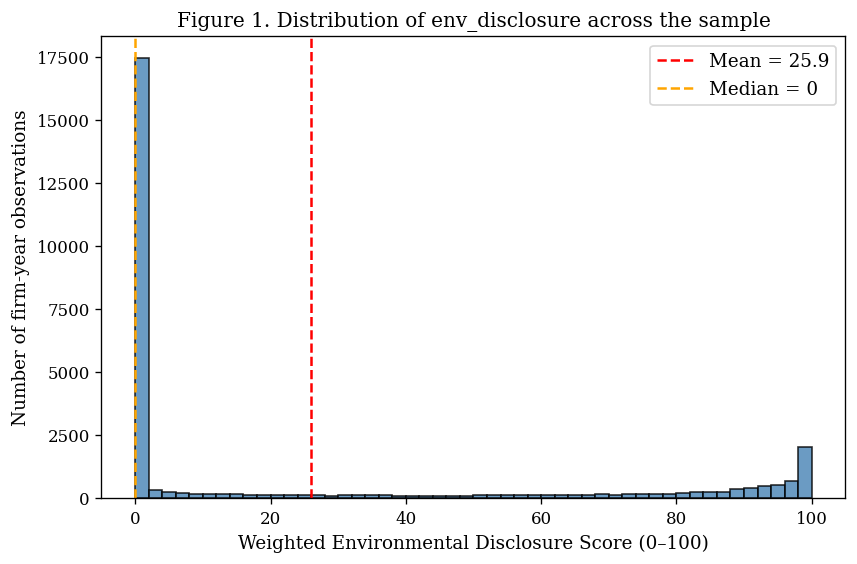

Figure 1 saved


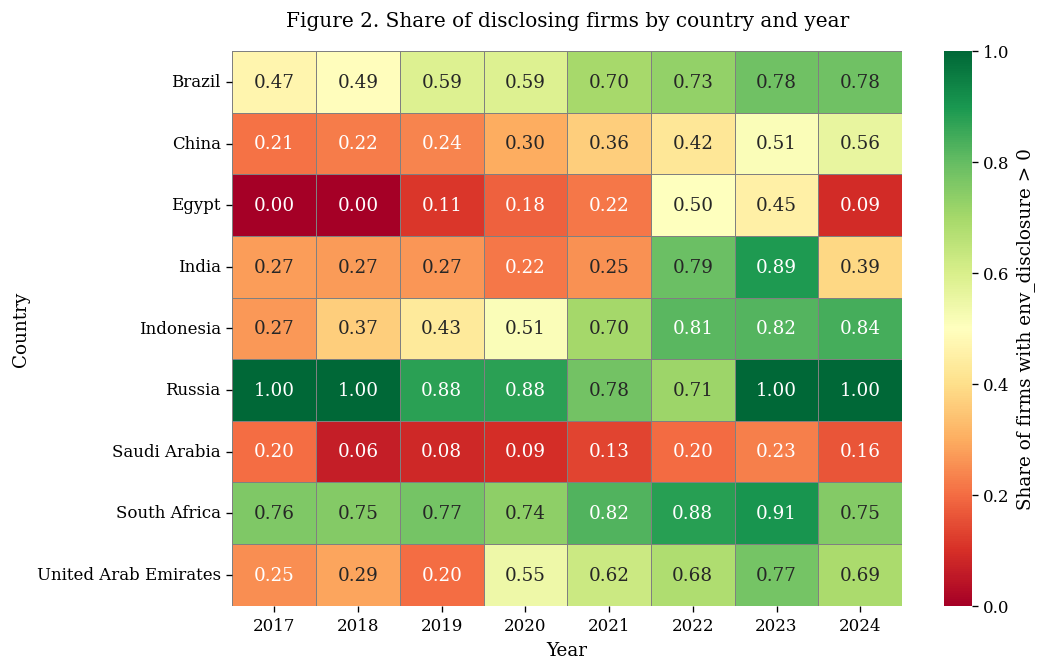

Figure 2 saved


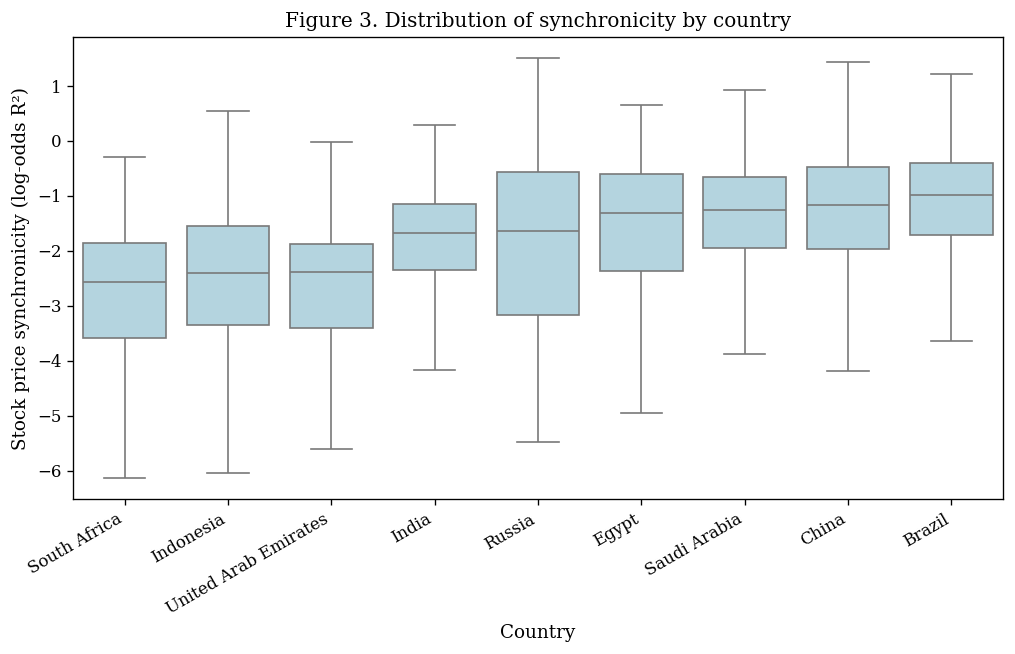

Figure 3 saved


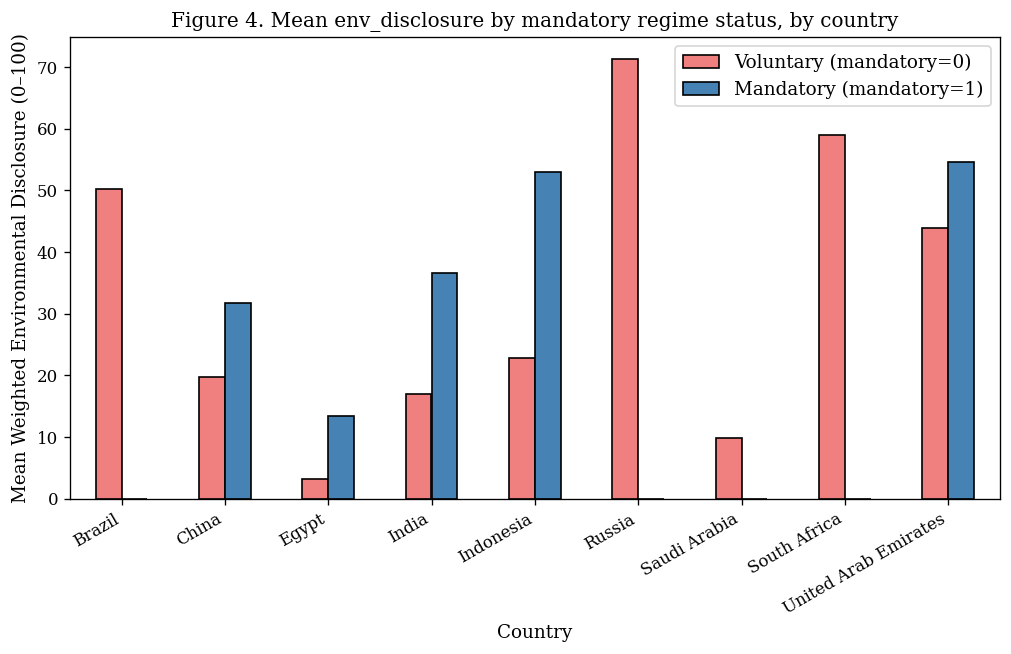

Figure 4 saved


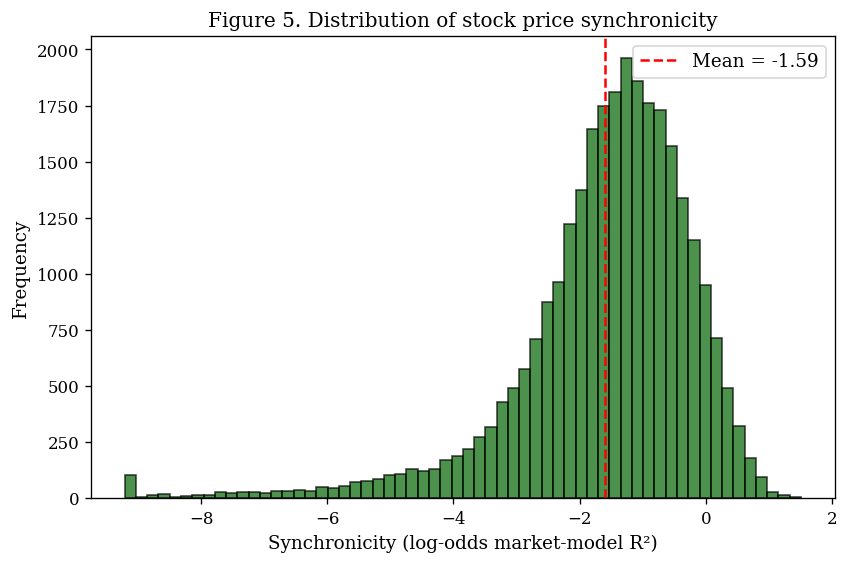

Figure 5 saved


In [46]:
print("=" * 70)
print("PART 2: FIGURES 1-9")
print("=" * 70)

# === Figure 1: Distribution of env_disclosure ===
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(panel["env_disclosure"], bins=50, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Weighted Environmental Disclosure Score (0–100)")
ax.set_ylabel("Number of firm-year observations")
ax.set_title("Figure 1. Distribution of env_disclosure across the sample")
ax.axvline(panel["env_disclosure"].mean(), color="red", linestyle="--",
           label=f"Mean = {panel['env_disclosure'].mean():.1f}")
ax.axvline(panel["env_disclosure"].median(), color="orange", linestyle="--",
           label=f"Median = {panel['env_disclosure'].median():.0f}")
ax.legend()
plt.savefig(DATA_DIR / "fig1_env_disc_dist.png")
plt.show()
print("Figure 1 saved")

# === Figure 2: Heatmap — disclosure share by country × year ===
panel["discloses"] = (panel["env_disclosure"] > 0).astype(int)
heat = panel.groupby(["country", "year"])["discloses"].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
    ax=ax, cbar_kws={"label": "Share of firms with env_disclosure > 0"},
    linewidths=0.5, linecolor="gray",
)
ax.set_title("Figure 2. Share of disclosing firms by country and year", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Country")
plt.savefig(DATA_DIR / "fig2_disclosure_heatmap.png")
plt.show()
print("Figure 2 saved")

# === Figure 3: Synchronicity boxplot by country ===
fig, ax = plt.subplots(figsize=(10, 5))
countries_ordered = panel.groupby("country")["synchronicity"].median().sort_values().index
sns.boxplot(
    data=panel, x="country", y="synchronicity", order=countries_ordered,
    color="lightblue", ax=ax, showfliers=False,
)
ax.set_xlabel("Country")
ax.set_ylabel("Stock price synchronicity (log-odds R²)")
ax.set_title("Figure 3. Distribution of synchronicity by country")
plt.xticks(rotation=30, ha="right")
plt.savefig(DATA_DIR / "fig3_synchronicity_by_country.png")
plt.show()
print("Figure 3 saved")

# === Figure 4: env_disclosure mean by mandatory status ===
disc_by_mand = panel.groupby(["country", "mandatory"])["env_disclosure"].mean().unstack(fill_value=np.nan)
disc_by_mand.columns = ["Voluntary (mandatory=0)", "Mandatory (mandatory=1)"]
fig, ax = plt.subplots(figsize=(10, 5))
disc_by_mand.plot(kind="bar", ax=ax, color=["lightcoral", "steelblue"], edgecolor="black")
ax.set_xlabel("Country")
ax.set_ylabel("Mean Weighted Environmental Disclosure (0–100)")
ax.set_title("Figure 4. Mean env_disclosure by mandatory regime status, by country")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.savefig(DATA_DIR / "fig4_disclosure_by_mandatory.png")
plt.show()
print("Figure 4 saved")

# === Figure 5: Synchronicity histogram ===
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(panel["synchronicity"].dropna(), bins=60, color="darkgreen", edgecolor="black", alpha=0.7)
ax.set_xlabel("Synchronicity (log-odds market-model R²)")
ax.set_ylabel("Frequency")
ax.set_title("Figure 5. Distribution of stock price synchronicity")
ax.axvline(panel["synchronicity"].mean(), color="red", linestyle="--",
           label=f"Mean = {panel['synchronicity'].mean():.2f}")
ax.legend()
plt.savefig(DATA_DIR / "fig5_synchronicity_dist.png")
plt.show()
print("Figure 5 saved")

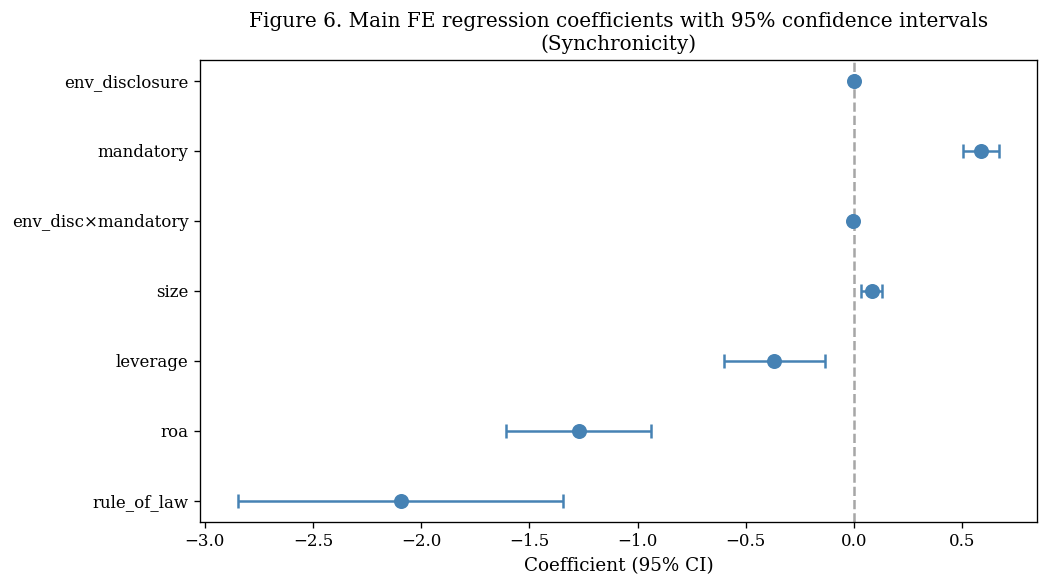

Figure 6 saved


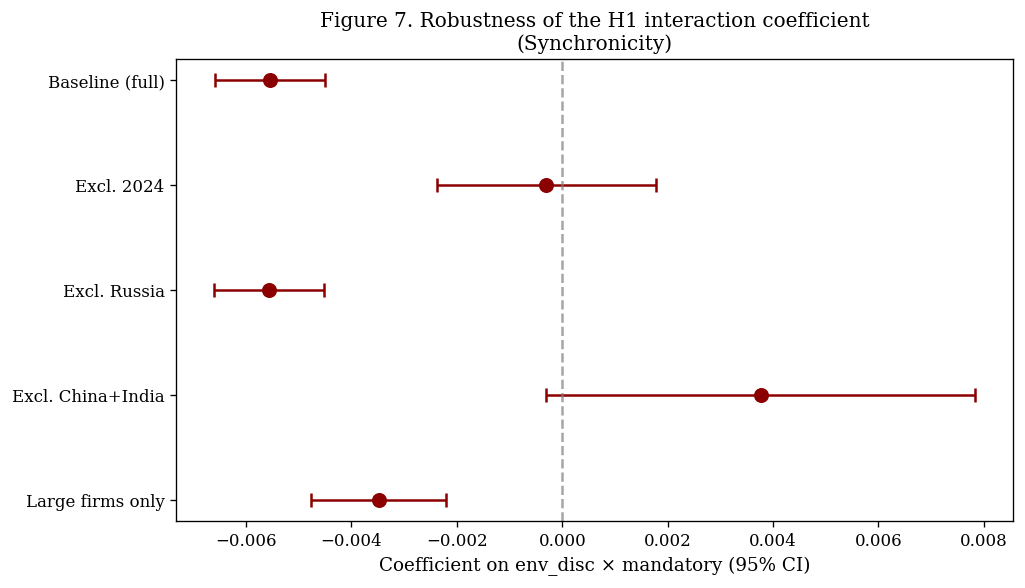

Figure 7 saved


In [47]:
# === Figure 6: Main FE coefficients (forest plot) ===
def get_main_fe(y_var):
    sub = panel.copy().set_index(["gvkey", "year"])
    sub["gsector"] = sub["gsector"].astype("category")
    ind = pd.get_dummies(sub["gsector"], prefix="sect", drop_first=True, dtype=float)
    sub["country"] = sub["country"].astype("category")
    cou = pd.get_dummies(sub["country"], prefix="country", drop_first=True, dtype=float)
    X = pd.concat([
        sub[[
            "env_disclosure", "mandatory", "env_disc_x_mandatory",
            "size", "leverage", "capex_ratio", "roa", "rule_of_law", "regulatory_quality",
        ]],
        ind, cou,
    ], axis=1)
    y = sub[y_var]
    df = pd.concat([y, X], axis=1).dropna()
    m = PanelOLS(
        df.iloc[:, 0],
        df.iloc[:, 1:].loc[:, df.iloc[:, 1:].std() > 1e-10],
        entity_effects=True, time_effects=True, drop_absorbed=True,
    )
    return m.fit(cov_type="clustered", cluster_entity=True)


vars_plot = ["env_disclosure", "mandatory", "env_disc_x_mandatory",
             "size", "leverage", "roa", "rule_of_law"]
labels = ["env_disclosure", "mandatory", "env_disc×mandatory",
          "size", "leverage", "roa", "rule_of_law"]
res_sync = get_main_fe("synchronicity")

fig, ax = plt.subplots(figsize=(9, 5))
coefs = [res_sync.params[v] for v in vars_plot]
ses = [res_sync.std_errors[v] for v in vars_plot]
y_pos = np.arange(len(vars_plot))
ax.errorbar(
    coefs, y_pos, xerr=[1.96 * s for s in ses], fmt="o", color="steelblue",
    capsize=4, capthick=1.5, markersize=8,
)
ax.axvline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Coefficient (95% CI)")
ax.set_title("Figure 6. Main FE regression coefficients with 95% confidence intervals\n(Synchronicity)")
ax.invert_yaxis()
plt.savefig(DATA_DIR / "fig6_main_forest.png")
plt.show()
print("Figure 6 saved")

# === Figure 7: Robustness forest ===
def get_inter_coef(panel_sub, y="synchronicity"):
    p_s = panel_sub.copy().set_index(["gvkey", "year"])
    p_s["gsector"] = p_s["gsector"].astype("category")
    ind = pd.get_dummies(p_s["gsector"], prefix="sect", drop_first=True, dtype=float)
    p_s["country"] = p_s["country"].astype("category")
    cou = pd.get_dummies(p_s["country"], prefix="country", drop_first=True, dtype=float)
    X = pd.concat([
        p_s[[
            "env_disclosure", "mandatory", "env_disc_x_mandatory",
            "size", "leverage", "capex_ratio", "roa",
            "rule_of_law", "regulatory_quality",
        ]],
        ind, cou,
    ], axis=1)
    yy = p_s[y]
    df = pd.concat([yy, X], axis=1).dropna()
    m = PanelOLS(
        df.iloc[:, 0],
        df.iloc[:, 1:].loc[:, df.iloc[:, 1:].std() > 1e-10],
        entity_effects=True, time_effects=True, drop_absorbed=True,
    )
    r = m.fit(cov_type="clustered", cluster_entity=True)
    if "env_disc_x_mandatory" in r.params.index:
        return r.params["env_disc_x_mandatory"], r.std_errors["env_disc_x_mandatory"]
    return np.nan, np.nan


robust_specs = {
    "Baseline (full)":      panel,
    "Excl. 2024":           panel[panel["year"] < 2024],
    "Excl. Russia":         panel[panel["country"] != "Russia"],
    "Excl. China+India":    panel[~panel["country"].isin(["China", "India"])],
    "Large firms only":     panel[panel["size"] > panel["size"].median()],
}

coefs_r, ses_r, labels_r = [], [], []
for name, sub in robust_specs.items():
    if len(sub) > 100:
        c, s = get_inter_coef(sub)
        if not np.isnan(c):
            coefs_r.append(c)
            ses_r.append(s)
            labels_r.append(name)

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(labels_r))
ax.errorbar(
    coefs_r, y_pos, xerr=[1.96 * s for s in ses_r], fmt="o", color="darkred",
    capsize=4, capthick=1.5, markersize=8,
)
ax.axvline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_r)
ax.set_xlabel("Coefficient on env_disc × mandatory (95% CI)")
ax.set_title("Figure 7. Robustness of the H1 interaction coefficient\n(Synchronicity)")
ax.invert_yaxis()
plt.savefig(DATA_DIR / "fig7_robustness_forest.png")
plt.show()
print("Figure 7 saved")

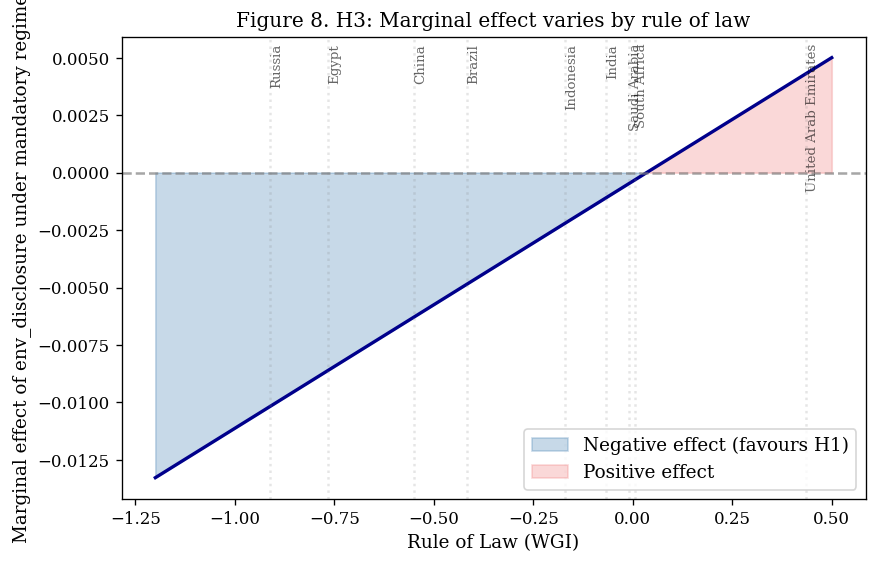

Figure 8 saved


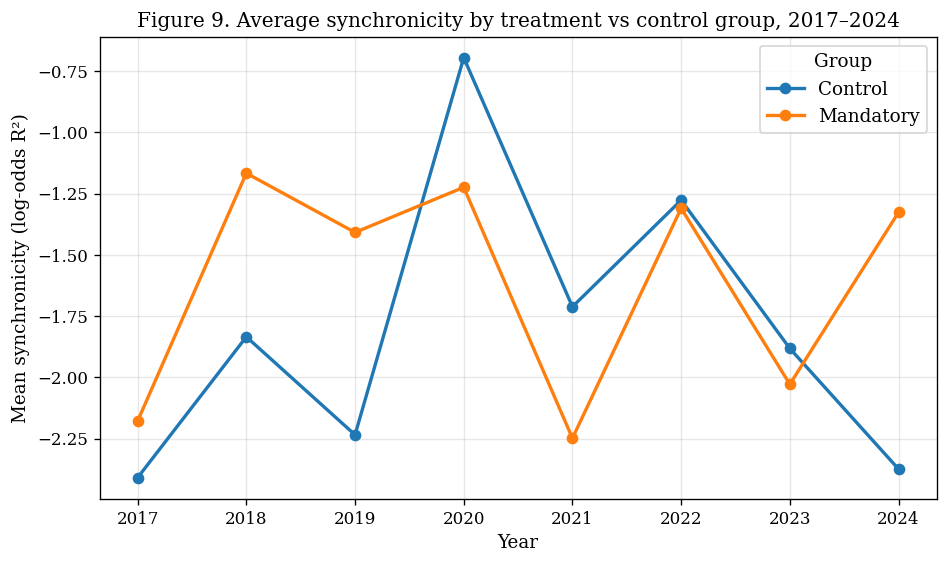

Figure 9 saved

All figures saved to /content/drive/MyDrive/diploma_esg
  fig1_*.png
  fig2_*.png
  fig3_*.png
  fig4_*.png
  fig5_*.png
  fig6_*.png
  fig7_*.png
  fig8_*.png
  fig9_*.png


In [48]:
# === Figure 8: H3 marginal effect by rule_of_law ===
panel["env_x_man_x_rol"] = panel["env_disc_x_mandatory"] * panel["rule_of_law"]
panel["env_x_rol"] = panel["env_disclosure"] * panel["rule_of_law"]
panel["man_x_rol"] = panel["mandatory"] * panel["rule_of_law"]

sub = panel.copy().set_index(["gvkey", "year"])
sub["gsector"] = sub["gsector"].astype("category")
ind = pd.get_dummies(sub["gsector"], prefix="sect", drop_first=True, dtype=float)
sub["country"] = sub["country"].astype("category")
cou = pd.get_dummies(sub["country"], prefix="country", drop_first=True, dtype=float)
X = pd.concat([
    sub[[
        "env_disclosure", "mandatory", "rule_of_law",
        "env_disc_x_mandatory", "env_x_rol", "man_x_rol", "env_x_man_x_rol",
        "size", "leverage", "capex_ratio", "roa", "regulatory_quality",
    ]],
    ind, cou,
], axis=1)
y = sub["synchronicity"]
df = pd.concat([y, X], axis=1).dropna()
m = PanelOLS(
    df.iloc[:, 0],
    df.iloc[:, 1:].loc[:, df.iloc[:, 1:].std() > 1e-10],
    entity_effects=True, time_effects=True, drop_absorbed=True,
)
r3 = m.fit(cov_type="clustered", cluster_entity=True)

b_edm = r3.params.get("env_disc_x_mandatory", 0)
b_triple = r3.params.get("env_x_man_x_rol", 0)
rol_range = np.linspace(-1.2, 0.5, 100)
me = b_edm + b_triple * rol_range

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rol_range, me, color="darkblue", linewidth=2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.fill_between(
    rol_range, me, 0, where=(me < 0),
    color="steelblue", alpha=0.3, label="Negative effect (favours H1)",
)
ax.fill_between(
    rol_range, me, 0, where=(me >= 0),
    color="lightcoral", alpha=0.3, label="Positive effect",
)
ax.set_xlabel("Rule of Law (WGI)")
ax.set_ylabel("Marginal effect of env_disclosure under mandatory regime")
ax.set_title("Figure 8. H3: Marginal effect varies by rule of law")
country_rol = panel.groupby("country")["rule_of_law"].mean()
for cc, rr in country_rol.items():
    ax.axvline(rr, color="gray", alpha=0.2, linestyle=":")
    ax.text(rr, ax.get_ylim()[1] * 0.95, cc,
            rotation=90, fontsize=8, verticalalignment="top", alpha=0.6)
ax.legend(loc="lower right")
plt.savefig(DATA_DIR / "fig8_h3_marginal_effect.png")
plt.show()
print("Figure 8 saved")

# === Figure 9: Time trends of synchronicity by treatment status ===
mandatory_countries = ["China", "India", "Indonesia", "Egypt", "United Arab Emirates"]
panel["group"] = panel["country"].apply(lambda c: "Mandatory" if c in mandatory_countries else "Control")
sync_by_year = panel.groupby(["group", "year"])["synchronicity"].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(9, 5))
sync_by_year.plot(ax=ax, marker="o", linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Mean synchronicity (log-odds R²)")
ax.set_title("Figure 9. Average synchronicity by treatment vs control group, 2017–2024")
ax.legend(title="Group")
ax.grid(True, alpha=0.3)
plt.savefig(DATA_DIR / "fig9_time_trends.png")
plt.show()
print("Figure 9 saved")

print(f"\nAll figures saved to {DATA_DIR}")
for i in range(1, 10):
    print(f"  fig{i}_*.png")

## 21. Balanced-panel disclosure heatmap

A balanced sub-panel of firms continuously present every year 2018–2024 isolates
the genuine behavioural response from compositional changes in the Trucost sample.

In [49]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

# Firms present in EVERY year 2018-2024
years_needed = set(range(2018, 2025))
firm_years = panel.groupby("gvkey")["year"].apply(set)
balanced_firms = firm_years[firm_years.apply(lambda x: years_needed.issubset(x))].index
print(f"Balanced panel firms (present every year 2018-2024): {len(balanced_firms):,}")

panel_bal = panel[panel["gvkey"].isin(balanced_firms)].copy()
panel_bal["discloses"] = (panel_bal["env_disclosure"] > 0).astype(int)

print("\n=== Disclosure share on FULL sample (for comparison) ===")
full_heat = panel.assign(discloses=(panel["env_disclosure"] > 0).astype(int)) \
                 .groupby(["country", "year"])["discloses"].mean().unstack().round(2)
print(full_heat)

print("\n=== Disclosure share on BALANCED panel (key check) ===")
bal_heat = panel_bal.groupby(["country", "year"])["discloses"].mean().unstack().round(2)
print(bal_heat)

print("\n=== Firms by country in the balanced panel ===")
print(panel_bal.groupby("country")["gvkey"].nunique())

# India 2021 -> 2022 change is the key test
print("\n=== India: change 2021 -> 2022 ===")
for label, df in [("Full sample", panel), ("Balanced panel", panel_bal)]:
    india = df[df["country"] == "India"].copy()
    india["discloses"] = (india["env_disclosure"] > 0).astype(int)
    by_year = india.groupby("year")["discloses"].mean()
    print(f"  {label:<18}: 2021={by_year.get(2021, np.nan):.2f}  "
          f"2022={by_year.get(2022, np.nan):.2f}  "
          f"diff={by_year.get(2022, 0) - by_year.get(2021, 0):.2f}")

bal_heat.to_excel(DATA_DIR / "disclosure_heatmap_balanced.xlsx")
print("\nSaved: disclosure_heatmap_balanced.xlsx")

Balanced panel firms (present every year 2018-2024): 2,129

=== Disclosure share on FULL sample (for comparison) ===
year                  2017  2018  2019  2020  2021  2022  2023  2024
country                                                             
Brazil                0.47  0.49  0.59  0.59  0.70  0.73  0.78  0.78
China                 0.21  0.22  0.24  0.30  0.36  0.42  0.51  0.56
Egypt                 0.00  0.00  0.11  0.18  0.22  0.50  0.45  0.09
India                 0.27  0.27  0.27  0.22  0.25  0.79  0.89  0.39
Indonesia             0.27  0.37  0.43  0.51  0.70  0.81  0.82  0.84
Russia                1.00  1.00  0.88  0.88  0.78  0.71  1.00  1.00
Saudi Arabia          0.20  0.06  0.08  0.09  0.13  0.20  0.23  0.16
South Africa          0.76  0.75  0.77  0.74  0.82  0.88  0.91  0.75
United Arab Emirates  0.25  0.29  0.20  0.55  0.62  0.68  0.77  0.69

=== Disclosure share on BALANCED panel (key check) ===
year                  2017  2018  2019  2020  2021  2022  2023  2024

## 22. Lag-specification R² check

A focused diagnostic on the lag-1 specification — outputs all five R² metrics
(rsquared, within, between, overall, inclusive) for full reporting in the thesis.

In [50]:
panel = pd.read_parquet(DATA_DIR / "panel_regression_ready.parquet")

# Recreate the lag specification
panel = panel.sort_values(["gvkey", "year"]).copy()
for v in ["env_disclosure", "mandatory", "env_disc_x_mandatory"]:
    panel[f"{v}_lag"] = panel.groupby("gvkey")[v].shift(1)

sub = panel.dropna(subset=[
    "env_disclosure_lag", "mandatory_lag", "env_disc_x_mandatory_lag",
    "synchronicity", "size", "leverage", "roa", "rule_of_law",
]).copy()

sub = sub.set_index(["gvkey", "year"])
sub["gsector"] = sub["gsector"].astype("category")
ind = pd.get_dummies(sub["gsector"], prefix="sect", drop_first=True, dtype=float)
sub["country"] = sub["country"].astype("category")
cou = pd.get_dummies(sub["country"], prefix="country", drop_first=True, dtype=float)

X = pd.concat([
    sub[[
        "env_disclosure_lag", "mandatory_lag", "env_disc_x_mandatory_lag",
        "size", "leverage", "capex_ratio", "roa", "rule_of_law", "regulatory_quality",
    ]],
    ind, cou,
], axis=1)
y = sub["synchronicity"]
df = pd.concat([y, X], axis=1).dropna()
X_c = df.iloc[:, 1:].loc[:, df.iloc[:, 1:].std() > 1e-10]
m = PanelOLS(df.iloc[:, 0], X_c, entity_effects=True, time_effects=True, drop_absorbed=True)
r = m.fit(cov_type="clustered", cluster_entity=True)

print("=== Lag specification: all R² metrics ===")
print(f"rsquared           : {r.rsquared:.4f}")
print(f"rsquared_within    : {r.rsquared_within:.4f}")
print(f"rsquared_between   : {r.rsquared_between:.4f}")
print(f"rsquared_overall   : {r.rsquared_overall:.4f}")
print(f"rsquared_inclusive : {r.rsquared_inclusive:.4f}")
print(f"\nN observations     : {int(r.nobs):,}")
print(f"Coef env_disc_x_mandatory_lag : {r.params.get('env_disc_x_mandatory_lag', np.nan):.5f}")
print(f"SE                            : {r.std_errors.get('env_disc_x_mandatory_lag', np.nan):.5f}")
print(f"p-value                       : {r.pvalues.get('env_disc_x_mandatory_lag', np.nan):.4f}")

=== Lag specification: all R² metrics ===
rsquared           : 0.0289
rsquared_within    : -0.0098
rsquared_between   : -2.5604
rsquared_overall   : -2.0759
rsquared_inclusive : 0.6991

N observations     : 21,258
Coef env_disc_x_mandatory_lag : -0.00047
SE                            : 0.00084
p-value                       : 0.5741


---

**End of analysis.** The regression-ready panel and all intermediate datasets are
saved to `DATA_DIR`. Figures 1–9 referenced in the thesis are produced in Section 20
and saved as PNG files. The complete summary of main results is in `table_all_results.xlsx`.